<h2 style="color:royalblue" align="center">STUDENT PERFORMANCE INDICATOR

## 1. Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch, and Test preparation course.

## 2. Data collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 columns and 1000 rows.

### 2.1. Import data and required packages
####  Importing pandas, numpy, matplotlib, seaborn and warnings library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
# Set plot style
sns.set_theme(style="whitegrid")

# Set font family for all text in seaborn plots
sns.set_context("notebook", font_scale=1.5, rc={"font.size":22, "axes.titlesize":22, "axes.labelsize":25})

#### Import the csv data as pandas dataFrame

In [3]:
df = pd.read_csv('../data/StudentsPerformance.csv')

#### Taking a picture of the data 

In [4]:
df.head(10) # First 10 Rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [5]:
df.tail(10) # Last 10 Rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [6]:
# Standardise column names—Clean column names: lower case, replace spaces/slashes with underscores
df.columns = [col.strip().lower().replace(' ', '_').replace('/', '_') for col in df.columns]

print(df.columns)

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')


#### Shape of the dataset

In [7]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender: sex of students  -> (Male/female)
- race/ethnicity: ethnicity of students -> (Group A, B, C, D, E)
- parental level of education: parents' final education -> (bachelor's degree, some college, master's degree, associate's degree, high school)
- lunch: having lunch before the test (standard or free/reduced) 
- test preparation course: complete or not complete before the test
- math score
- reading score
- writing score

## 3. Data checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of the data set
- Check various categories present in the different categorical columns

### 3.1. Check missing values

In [8]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2. Check duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3. Check data types

In [10]:
# Check Null and Dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4. Checking the number of unique values of each column

In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5. Check statistics of data set

In [12]:
df.describe().T.sort_values(by='std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
writing_score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0
math_score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading_score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0


#### Insight
- From the above description of numerical data, all means are very close to each other, between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score of 0 for math, for writing, the minimum is much higher = 10 and for reading, much higher = 17

### 3.6. Exploring data

In [13]:
print("Categories in 'gender' variable: ", end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ", end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable: ", end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable: ", end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  ['female' 'male']
Categories in 'race_ethnicity' variable:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in'parental level of education' variable:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:  ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [14]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features: {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features: {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### 3.7. Adding columns for "Total Score" and "Average"

In [15]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'The number of students with full marks in Maths: {math_full}')
print(f'The number of students with full marks in Writing: {writing_full}')
print(f'The number of students with full marks in Reading: {reading_full}')

The number of students with full marks in Maths: 7
The number of students with full marks in Writing: 14
The number of students with full marks in Reading: 17


In [17]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'The number of students with less than 20 marks in Maths: {math_less_20}')
print(f'The number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'The number of students with less than 20 marks in Reading: {reading_less_20}')

The number of students with less than 20 marks in Maths: 4
The number of students with less than 20 marks in Writing: 3
The number of students with less than 20 marks in Reading: 1


#####  Insights
 - From the above values, we see that students have performed the worst in Maths 
 - Best performance is in the reading section

## 4. Visualisation 
### 4.1. Visualise numerical variables of the dataset 

In [18]:
def _plot_numeric_classes(df, col, bins=10, kde=True):
    sns.histplot(df[col], bins = bins, kde = kde)
    plt.tight_layout()

def _distribution_numeric(df, numeric_cols, row=3, col=3, figsize=(20, 15), bins=10):
    '''
    numeric_cols..... List of the feature names
    row.............. The number of rows in a single plot
    col.............. The number of columns in a single plot
    figsize.......... A parameter to change the size of a figure 
    bins............. The number of bins in the histogram   
    '''
    print("The number of the numeric field: ", len(numeric_cols))
    assert row*(col-1) < len(numeric_cols)
    plt.figure(figsize = figsize)
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.2, hspace=0.5)
    for i in range(1, len(numeric_cols)+1, 1):
        try:
            plt.subplot(row, col, i)
            _plot_numeric_classes(df, numeric_cols[i-1], bins=bins)
            plt.title(numeric_cols[i-1])
        except:
            print("Error {}".format(numeric_cols[i-1]))
            break

The number of the numeric field:  3


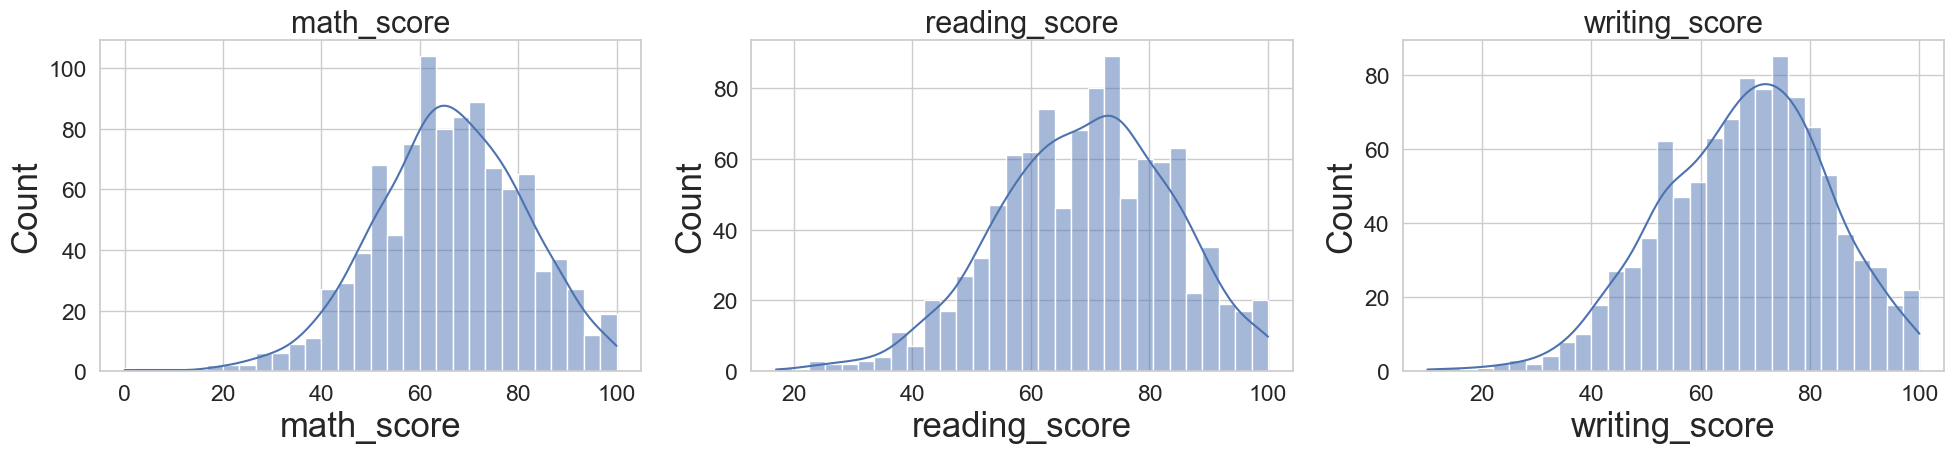

In [19]:
_distribution_numeric(df, numeric_features, 1, 3, (20, 5), 30)

In [20]:
new_numeric_features = df.select_dtypes(include=['float', 'int']).columns
print("The list of the numerical features: ", new_numeric_features)

The list of the numerical features:  Index(['math_score', 'reading_score', 'writing_score', 'total score',
       'average'],
      dtype='object')


The number of the numeric field:  5


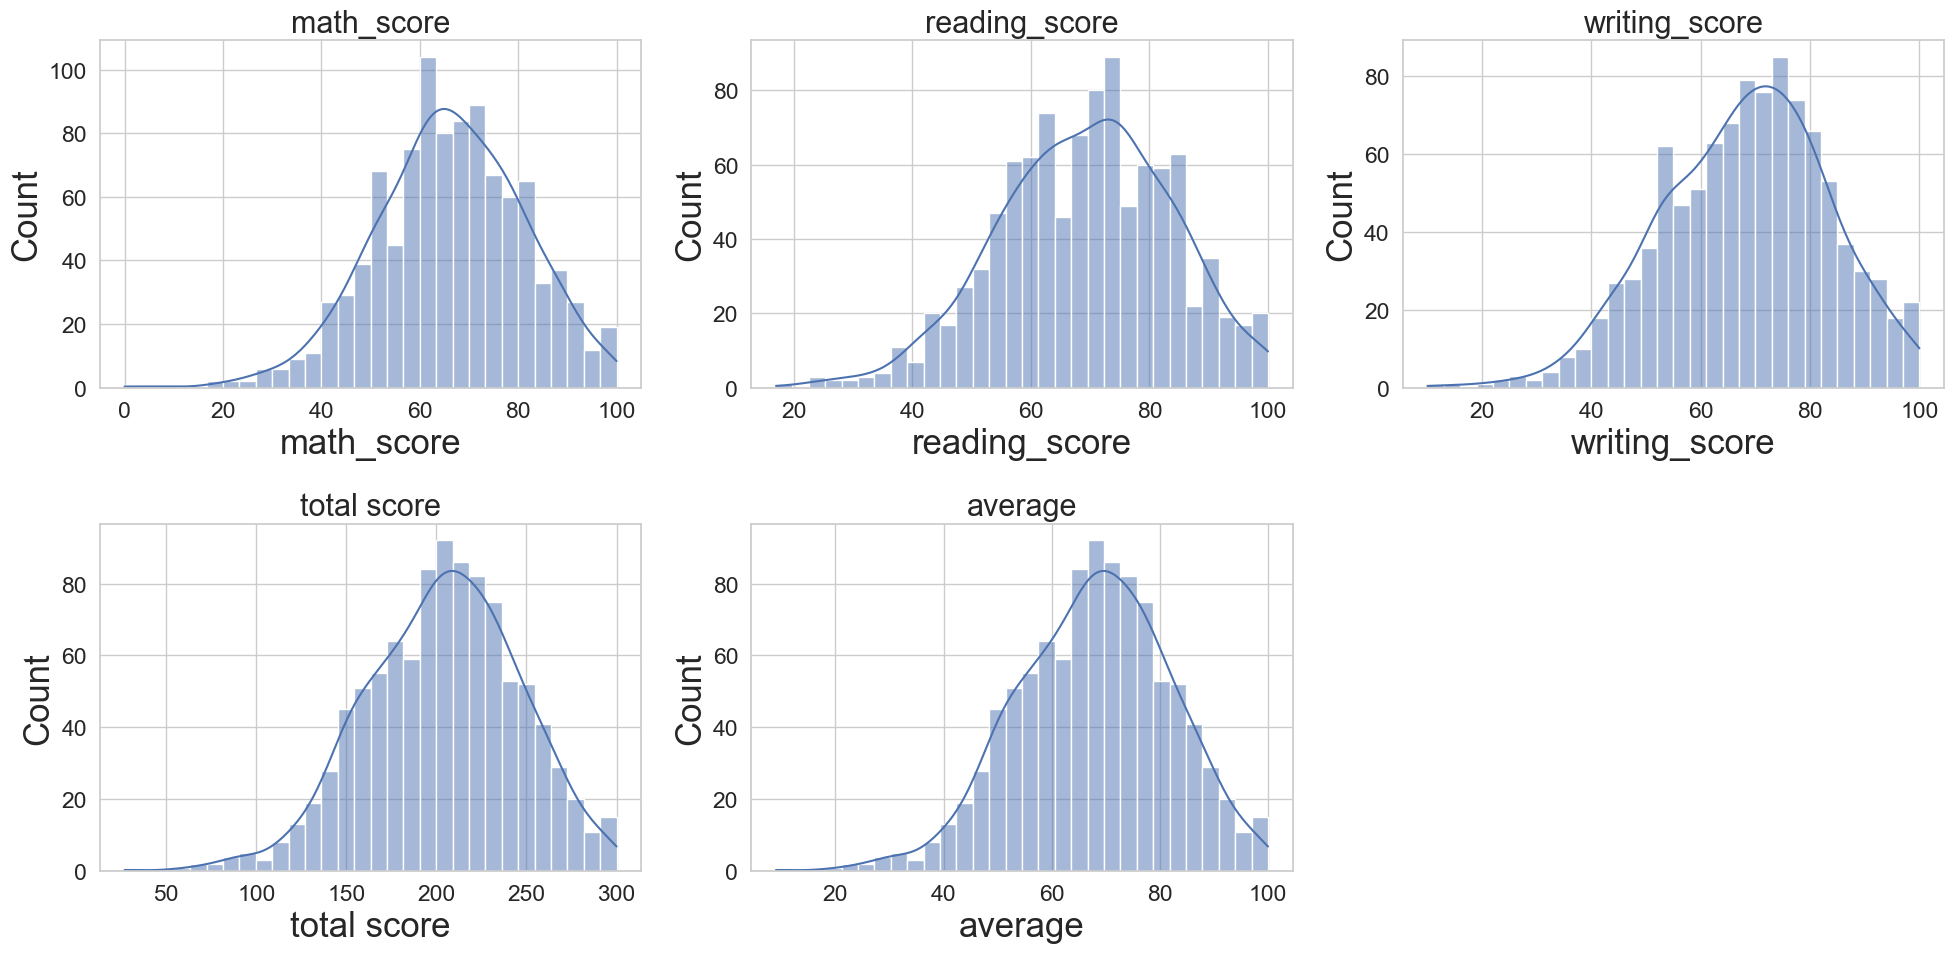

In [21]:
_distribution_numeric(df, new_numeric_features, 2, 3, (20, 10), 30)

### 4.2. Visualise the average and total score distribution to draw some conclusions
- Histogram
- Kernel Distribution Function (KDE)

#### 4.2.1. Histogram & KDE

##### - Group by gender

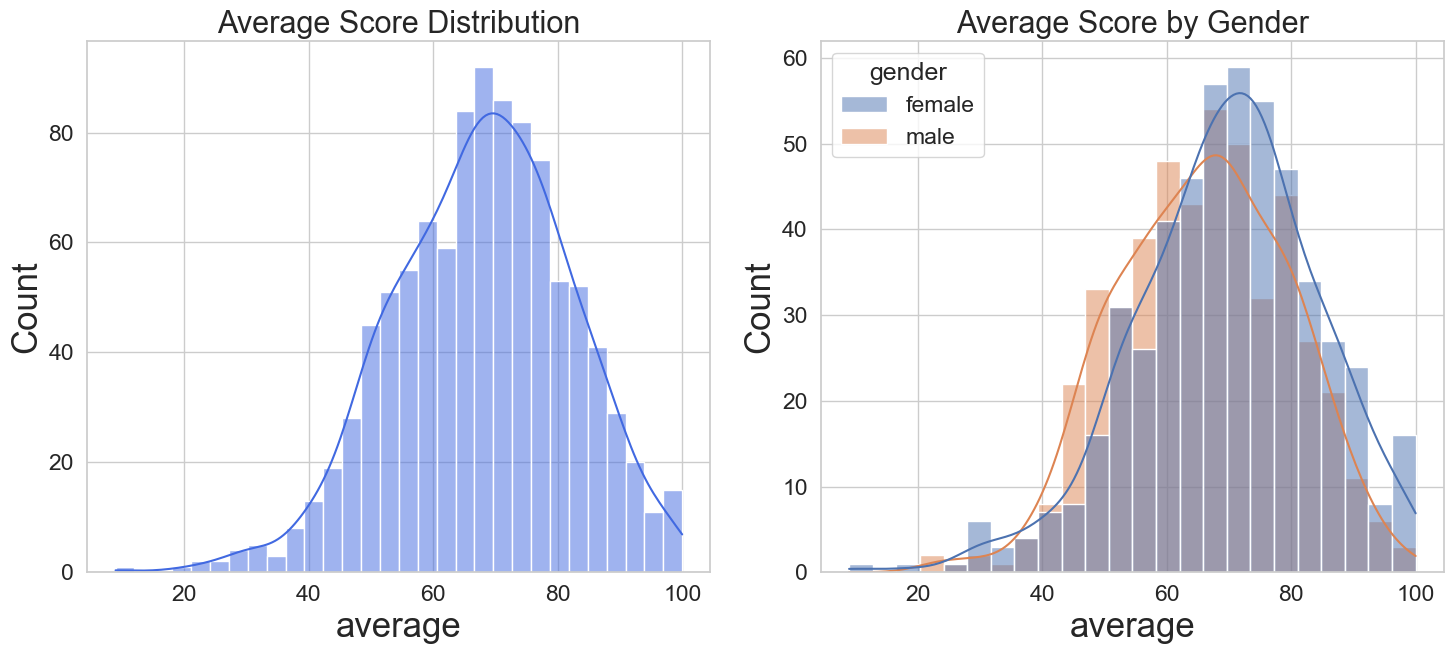

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='average', bins=30, kde=True, color='royalblue', ax=axs[0])
axs[0].set_title("Average Score Distribution")
sns.histplot(data=df, x='average', kde=True, hue='gender', ax=axs[1])
axs[1].set_title("Average Score by Gender")
sns.move_legend(axs[1], "upper left")
plt.tight_layout()

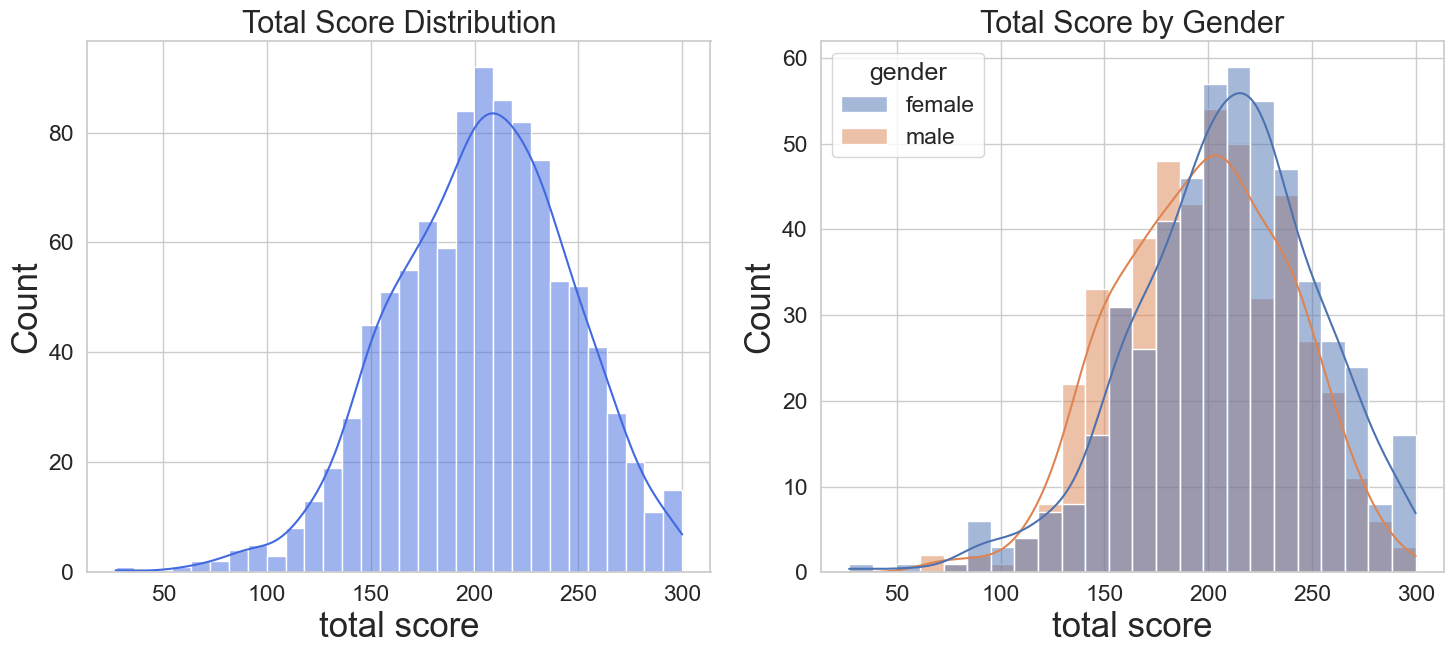

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
sns.histplot(data=df, x='total score', bins=30, kde=True, color='royalblue', ax=axs[0])
axs[0].set_title("Total Score Distribution")
sns.histplot(data=df, x='total score', kde=True, hue='gender', ax=axs[1])
axs[1].set_title("Total Score by Gender")
sns.move_legend(axs[1], "upper left")
plt.tight_layout()

#####  Insights
- Female students tend to perform better than male students.

##### - Group by lunch

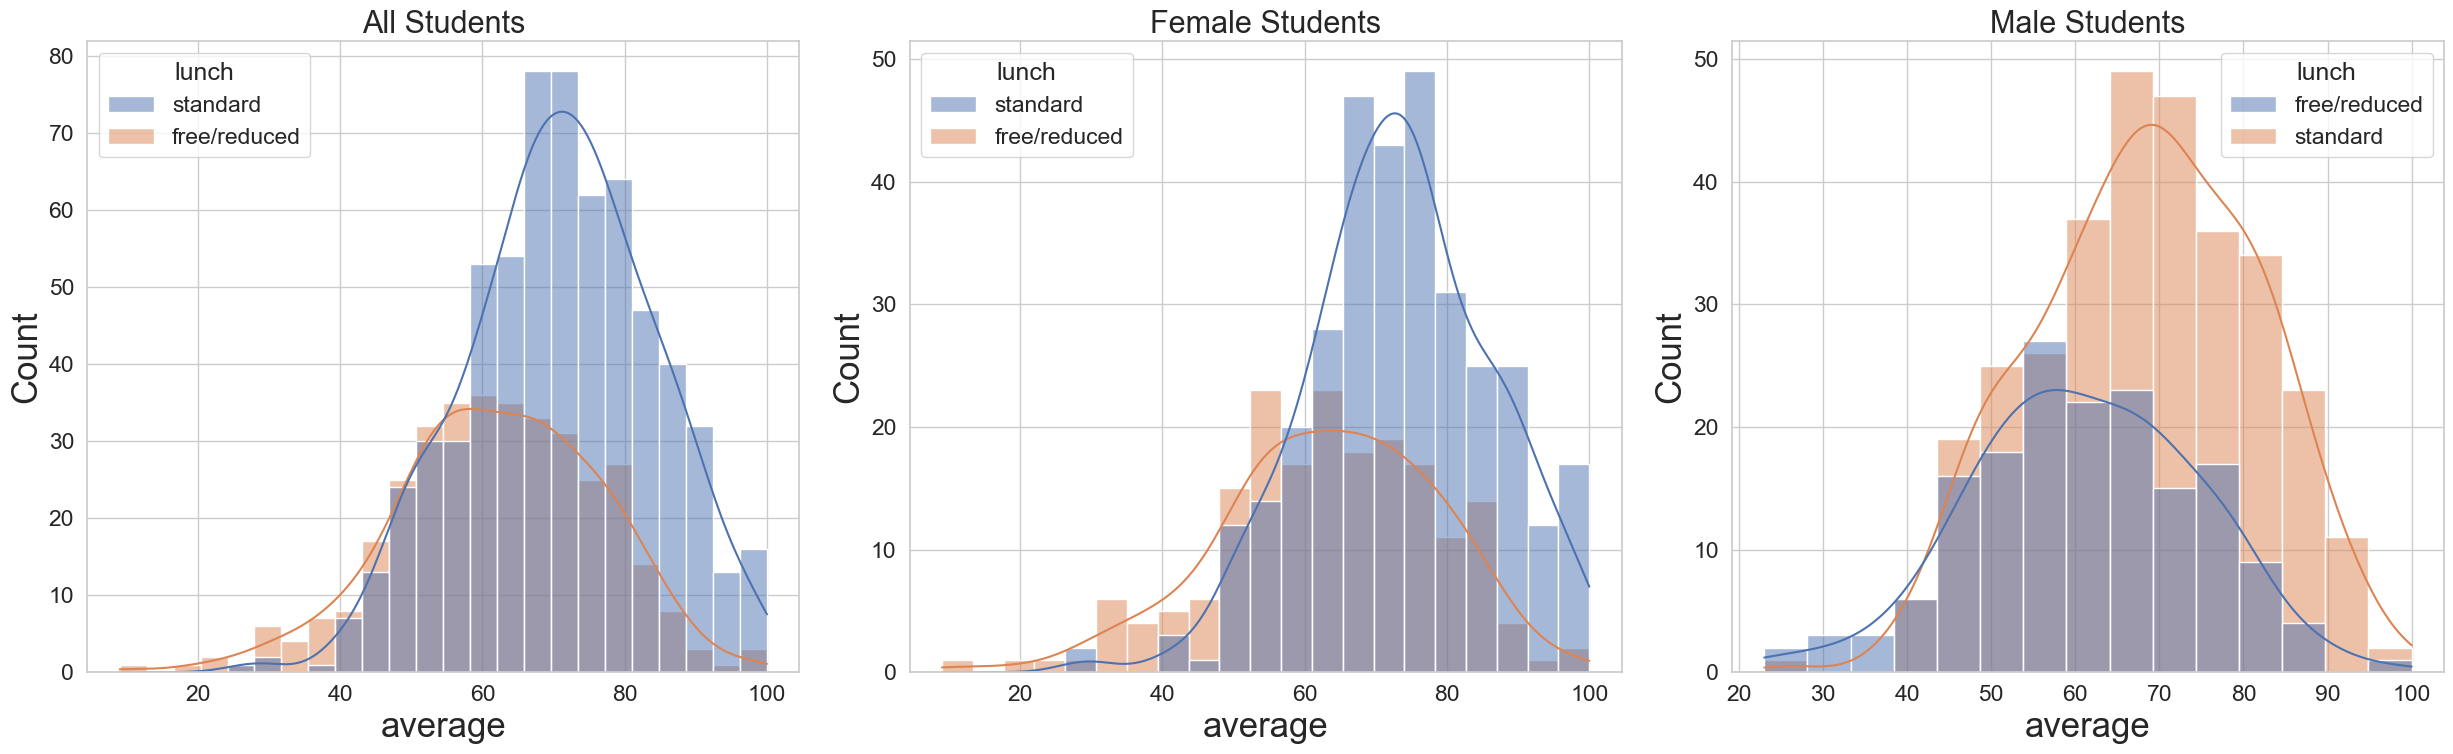

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8))

# All students
sns.histplot(data=df, x='average', kde=True, hue='lunch', ax=axs[0])
axs[0].set_title("All Students")

# Female Students
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch', ax=axs[1])
axs[1].set_title("Female Students")

# Male Students
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch', ax=axs[2])
axs[2].set_title("Male Students")

plt.tight_layout()

#####  Insights
- Standard lunch helps students perform better in exams.
- Standard lunch helps perform better in exams regardless of whether a male or a female.

##### - Group by parental_level_of_education

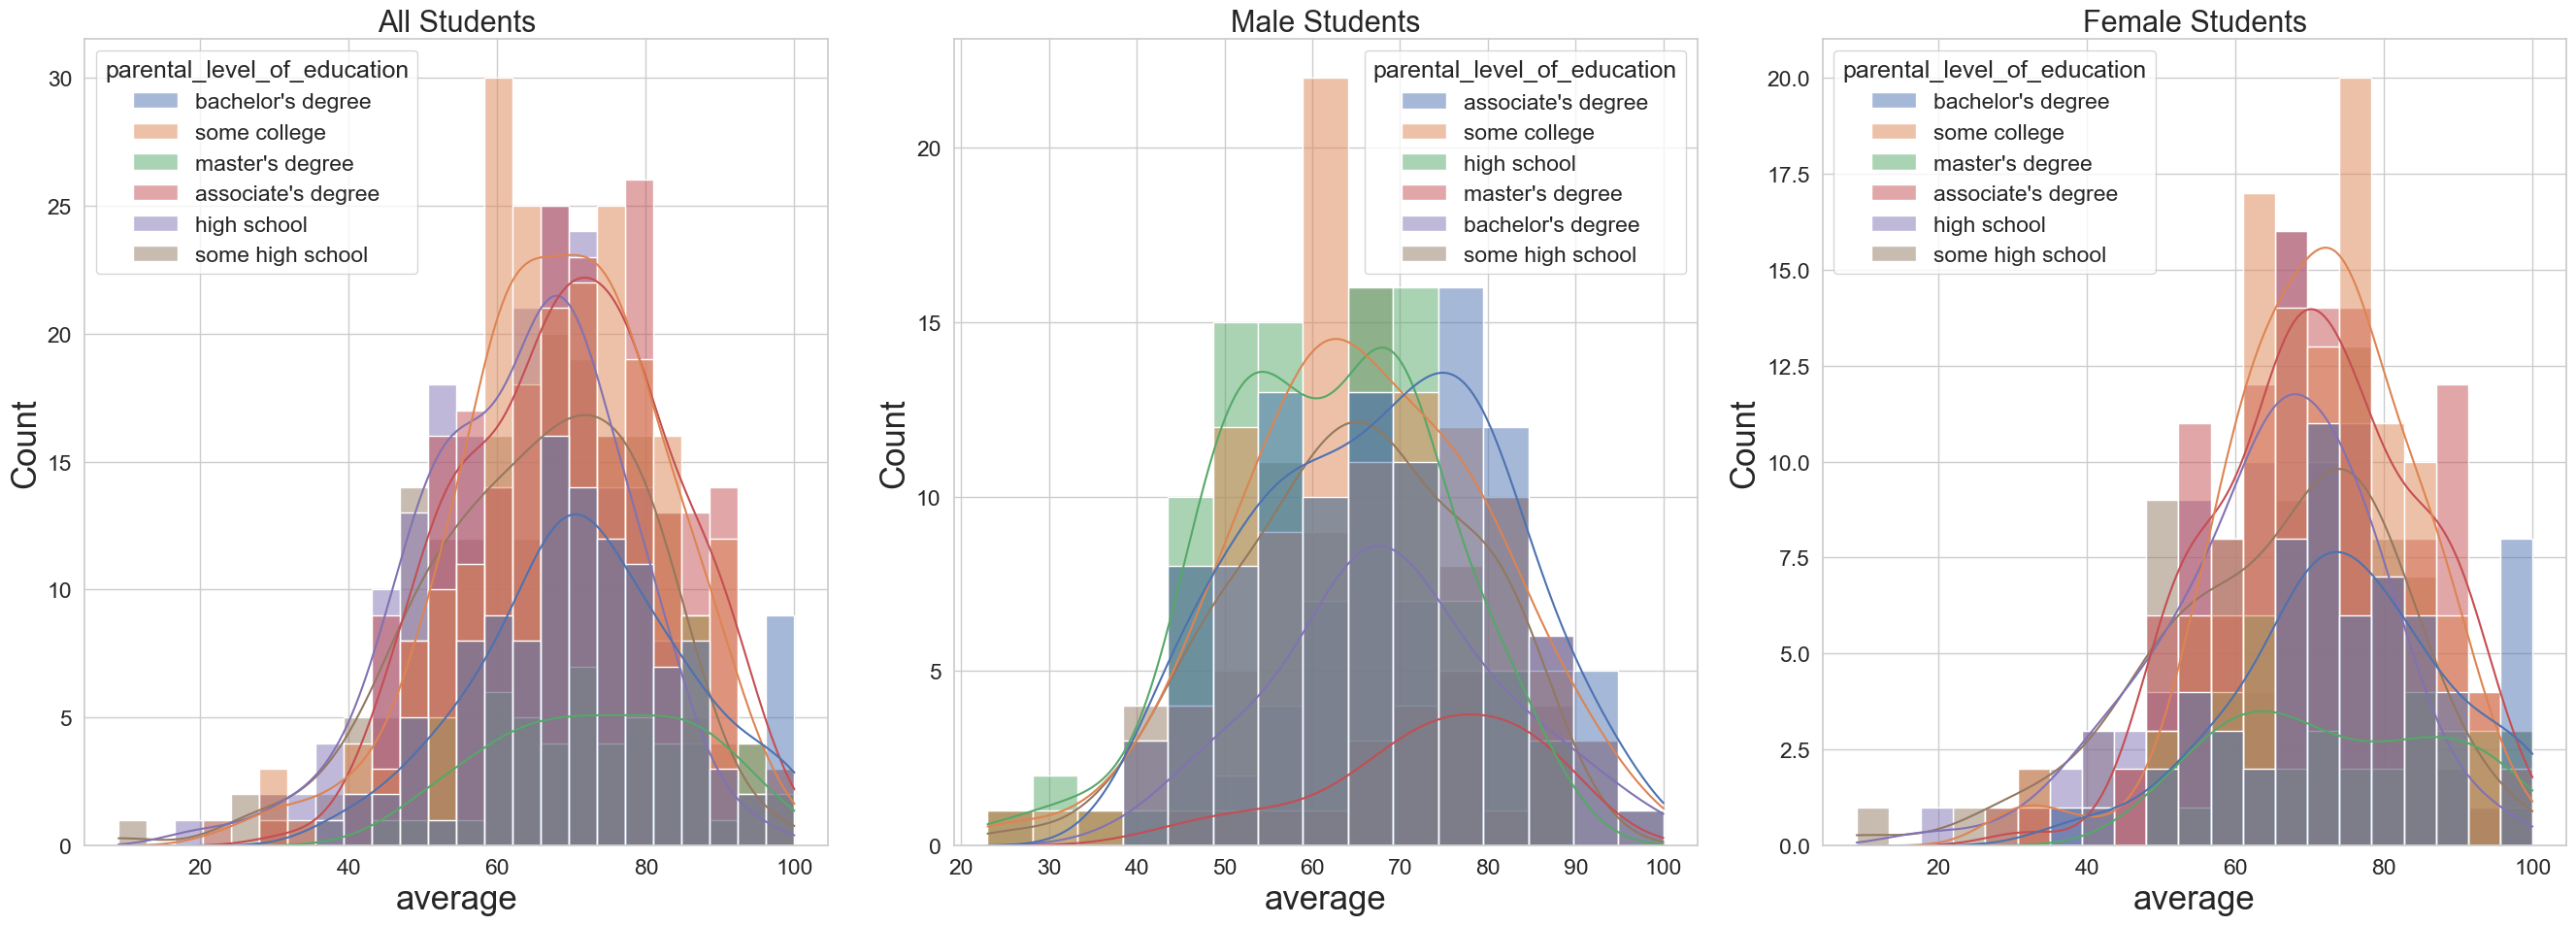

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(27, 10))

# All Students
sns.histplot(data=df, x='average', kde=True, hue='parental_level_of_education', ax=axs[0])
axs[0].set_title("All Students")

# Male Students
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='parental_level_of_education', ax=axs[1])
axs[1].set_title("Male Students")

# Female Students
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='parental_level_of_education', ax=axs[2])
axs[2].set_title("Female Students")

plt.tight_layout()

#####  Insights
- In general, parents' education does not help students perform well on exams.
- The 2nd plot shows that parents whose education is of an associate's degree or master's degree, their male child tends to perform well in exams
- 3rd plot, we can see there is no effect of parents' education on female students.

##### - Group by race_ethnicity

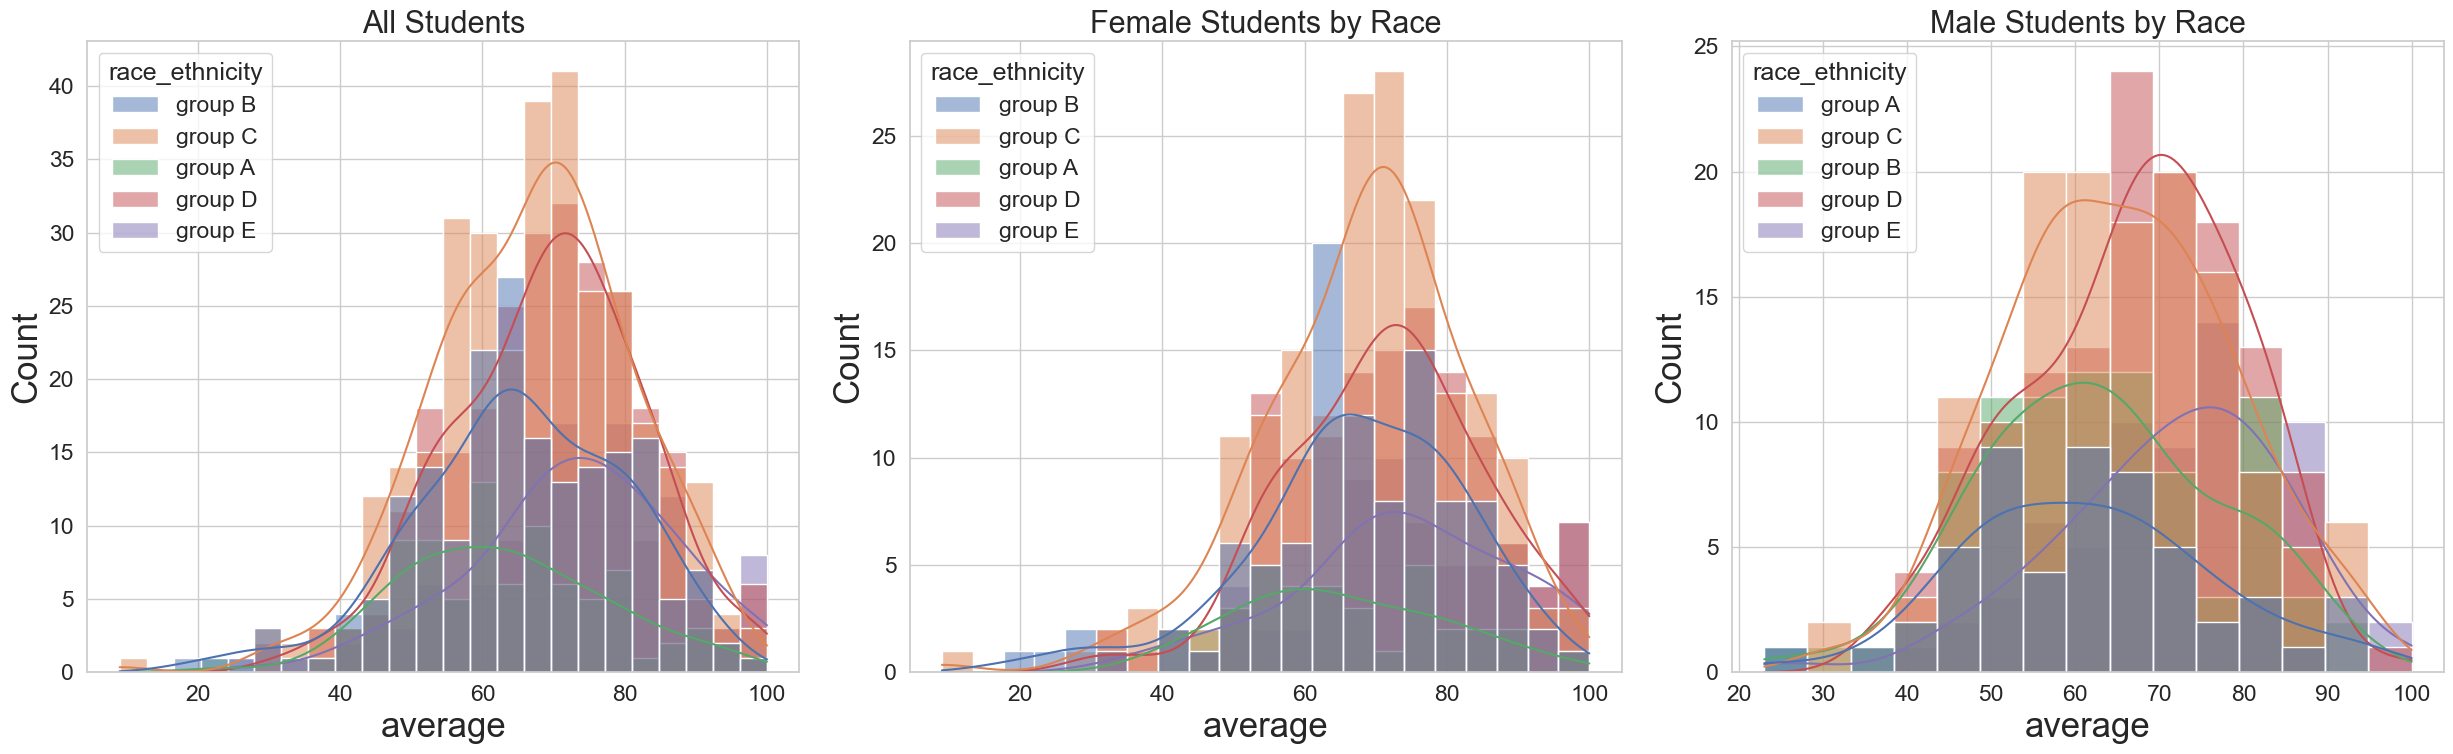

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8))

# All Students
sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity', ax=axs[0])
axs[0].set_title("All Students")
sns.move_legend(axs[0], "upper left")

# Female Students
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='race_ethnicity', ax=axs[1])
axs[1].set_title("Female Students by Race")
sns.move_legend(axs[1], "upper left")

# 4. Male Students
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='race_ethnicity', ax=axs[2])
axs[2].set_title("Male Students by Race")
sns.move_legend(axs[2], "upper left")

plt.tight_layout()

#####  Insights
- Students of group A and group B tend to perform poorly in the exam.
- Students of group A and group B tend to perform poorly in the exam, irrespective of whether they are male or female

#### 4.3. Maximumum score of students in all three subjects

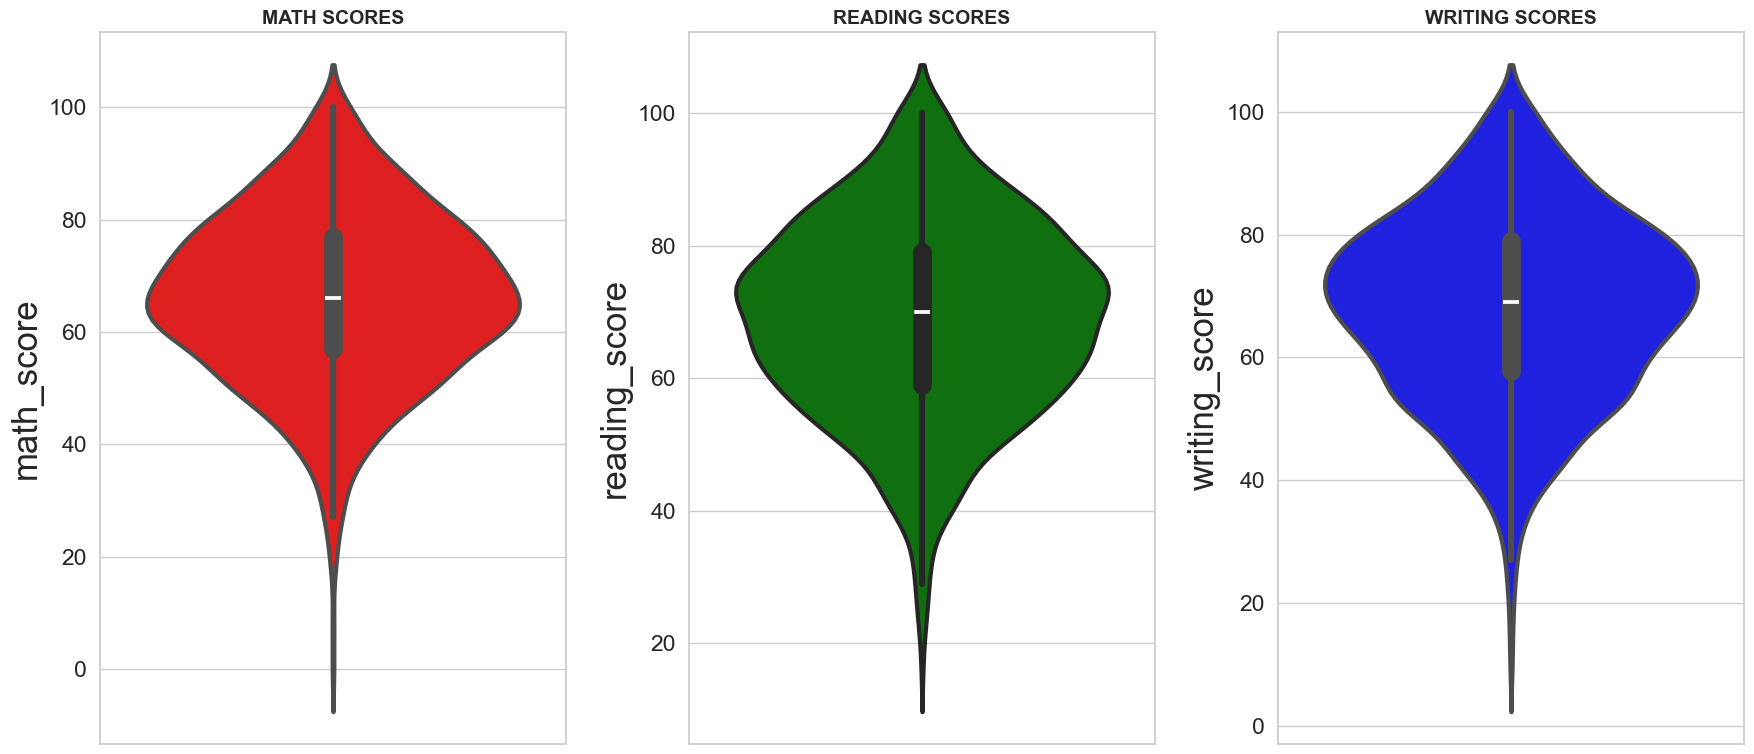

In [27]:
fig, axs = plt.subplots(1, 3, figsize=(18, 8))

# MATH SCORES
sns.violinplot(y='math_score', data=df, color='red', linewidth=3, ax=axs[0])
axs[0].set_title('MATH SCORES', fontsize=14, fontweight='bold')

# READING SCORES
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3, ax=axs[1])
axs[1].set_title('READING SCORES', fontsize=14, fontweight='bold')

# WRITING SCORES
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3, ax=axs[2])
axs[2].set_title('WRITING SCORES', fontsize=14, fontweight='bold')

plt.tight_layout()

#### Insights
- Overall, students in the dataset demonstrated very consistent and fairly high academic abilities, with Maths showing the most impressive results with the highest median score. However, Maths also showed the strongest differentiation in academic ability, with a wide range of scores towards the bottom, while Reading and Writing skills were more stable and showed less variation amongst student groups.

### 4.4. Multivariate analysis using pieplot

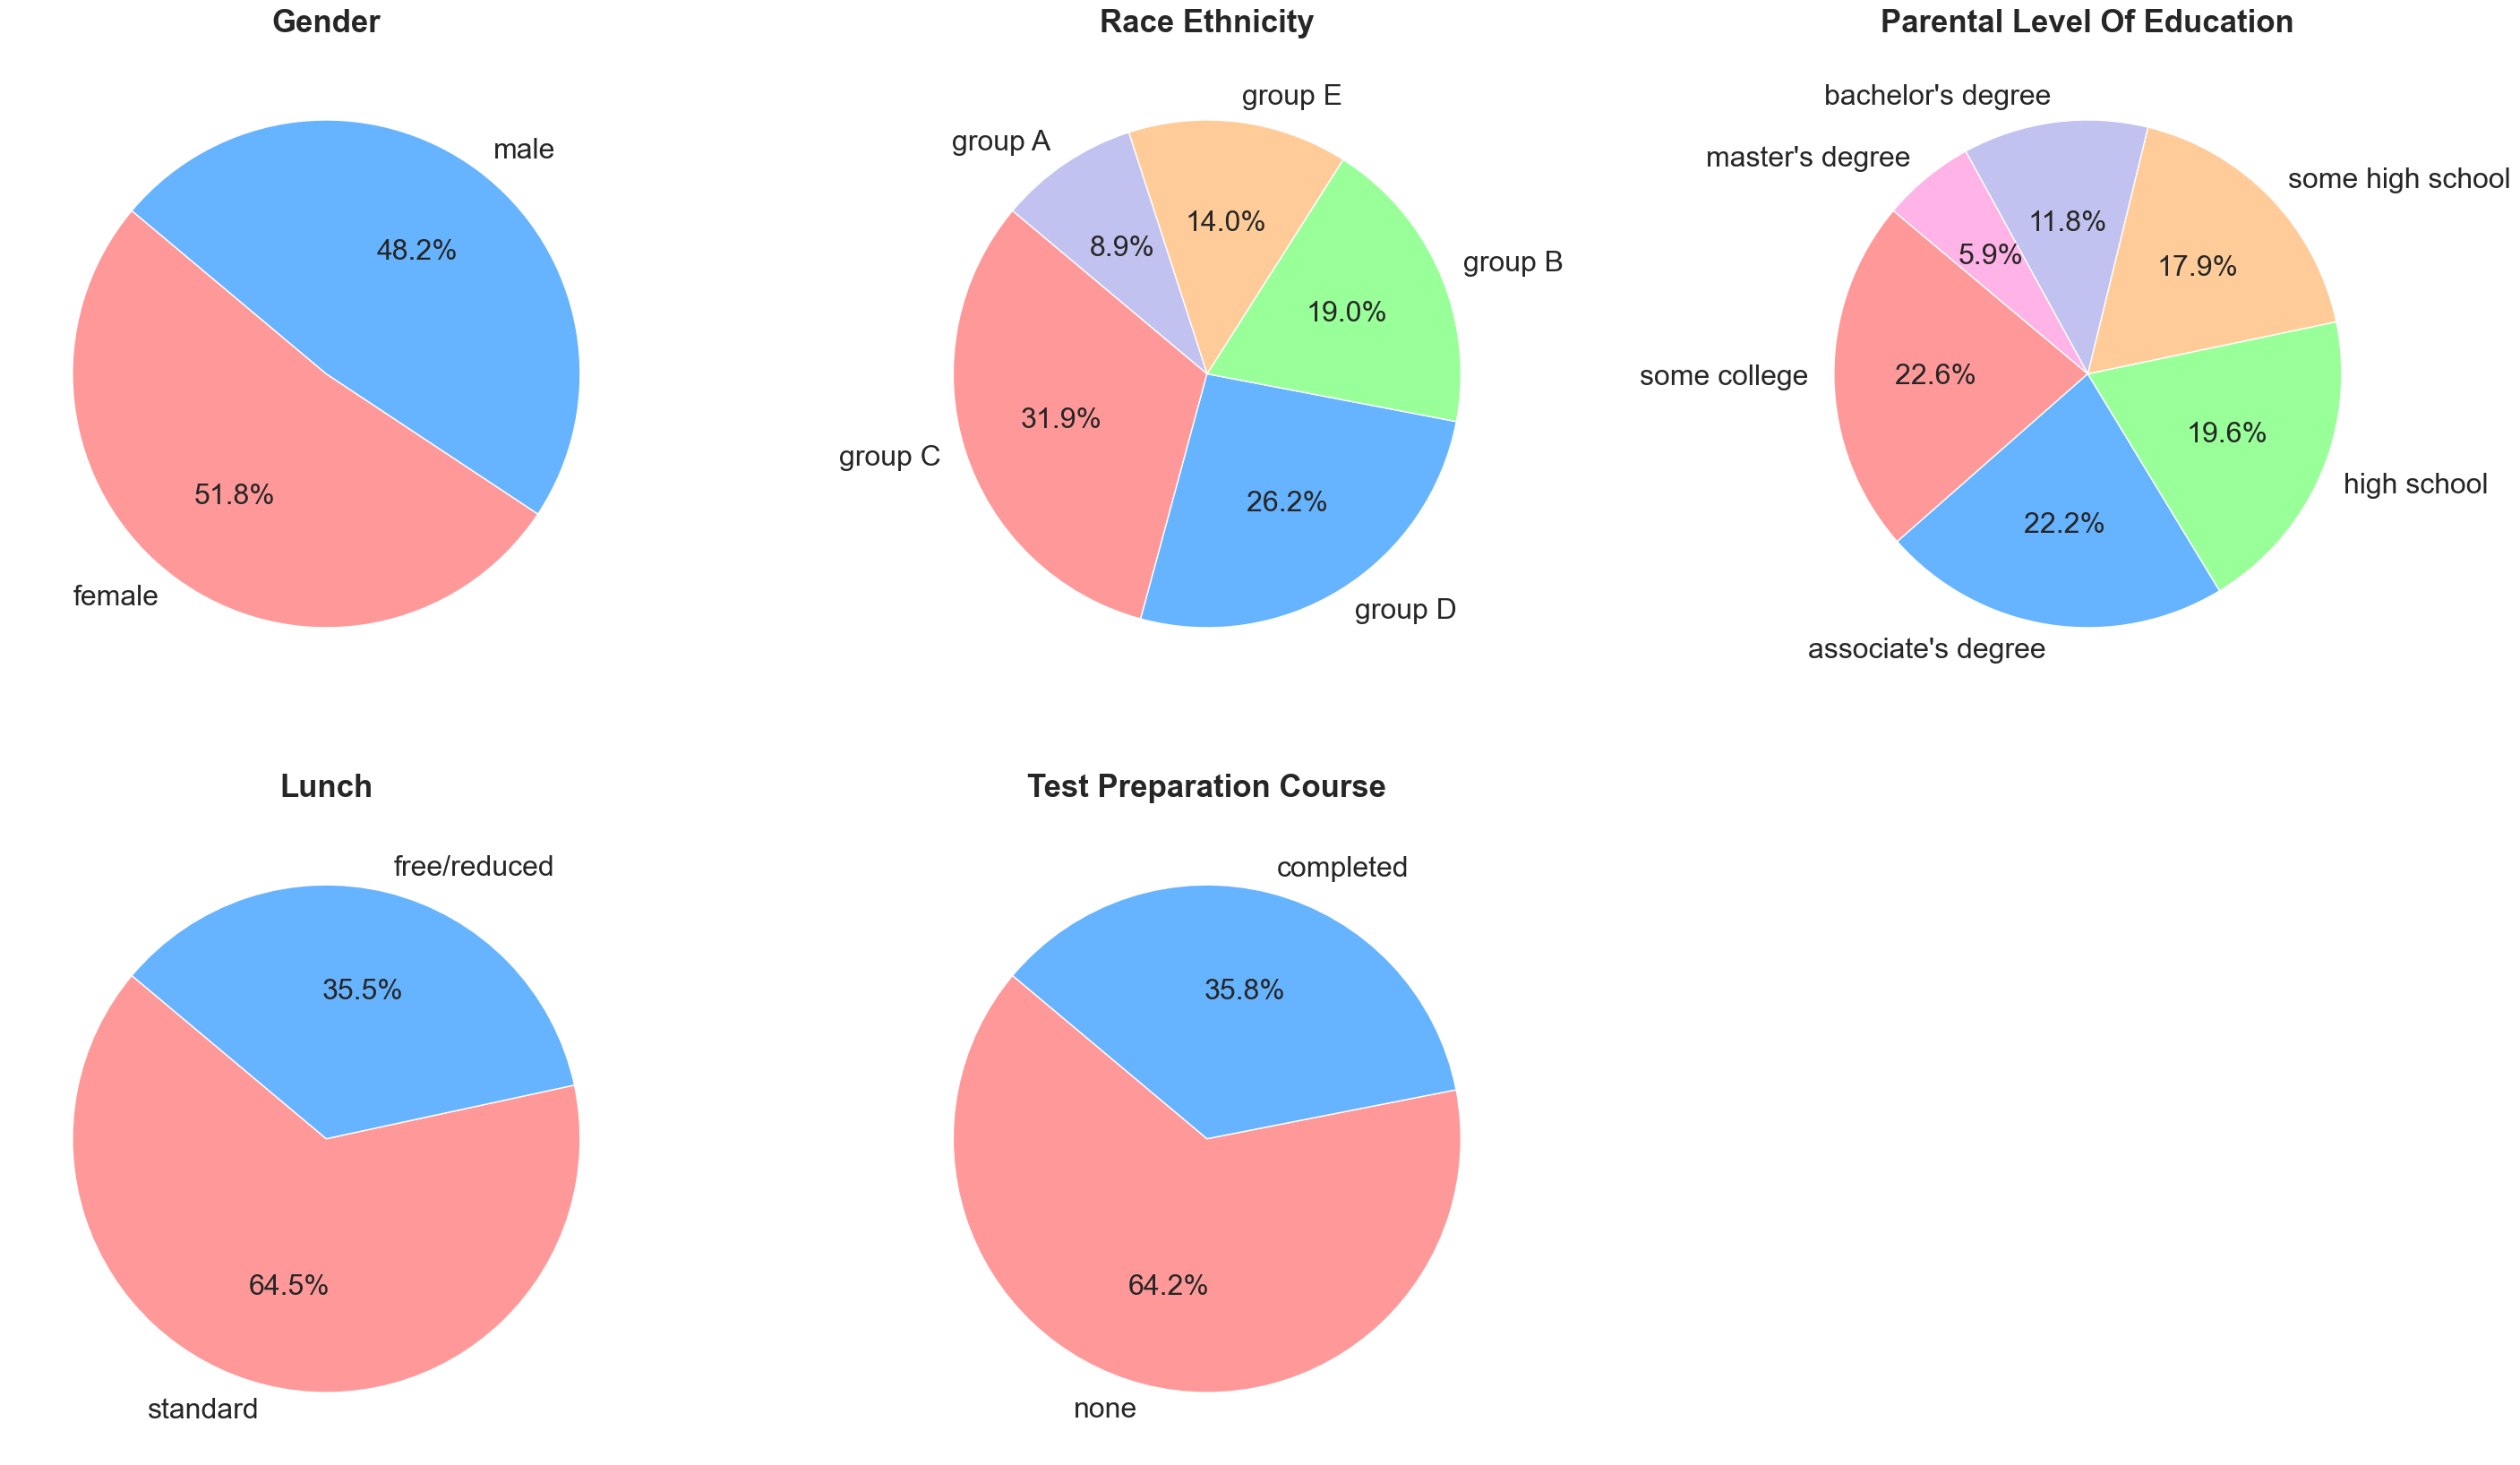

In [28]:
# List of features for pie chart
cols = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']

fig, axs = plt.subplots(2, 3, figsize=(30, 18)) 

# Colour scheme
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']

axs = axs.flatten() # Flatten the array axs to access it using a single index i (0 to 5).

# Pie chart
for i, col in enumerate(cols):
    size = df[col].value_counts()

    axs[i].pie(
        size, 
        labels=size.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        textprops={'fontsize': 23} 
    )
    
    axs[i].set_title(col.replace('_', ' ').title(), fontsize=25, fontweight='bold', pad=20)

axs[5].axis('off') # Turn off the last figure

plt.tight_layout(pad=3.0)

#####  Insights
- The number of Male and Female students is almost equal
- The number of students is greatest in Group C
- The number of students whose parental education is "Some College" is greater, followed closely by "Associate's Degree"
- The number of students who have standard lunch is greater
- The number of students who have not enrolled in any test preparation course is greater

### 4.5. Feature wise visualisation
#### 4.5.1. Gender column
- How is the distribution of Gender?
- Does gender have any impact on students' performance?

#### - Univariate analysis (How is the distribution of Gender?)

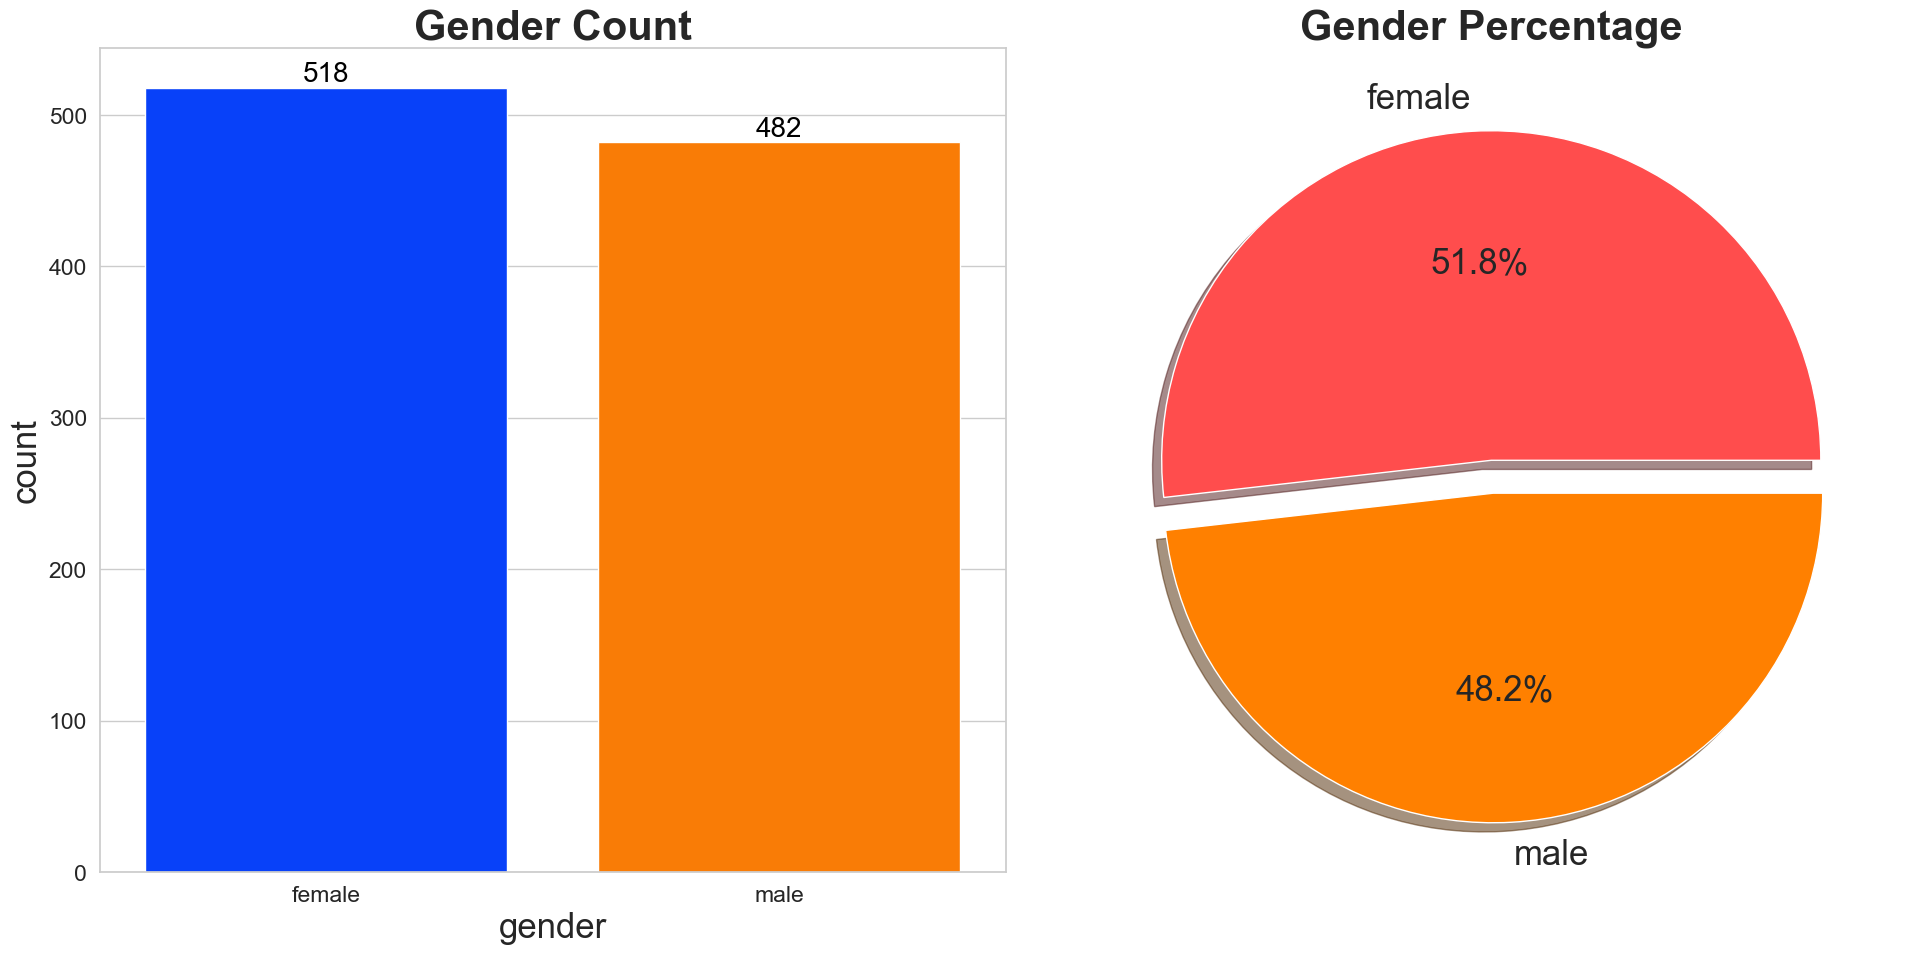

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Countplot
sns.countplot(x='gender', data=df, palette='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
ax[0].set_title('Gender Count', fontsize=30, fontweight='bold') 

# Pie chart
ax[1].pie(
    x=df['gender'].value_counts(), 
    labels=df['gender'].value_counts().index, 
    explode=[0, 0.1], 
    autopct='%1.1f%%', 
    shadow=True, 
    colors=['#ff4d4d', '#ff8000'],
    textprops={'fontsize': 25} 
)
ax[1].set_title('Gender Percentage', fontsize=30, fontweight='bold')

plt.tight_layout()

#### Insights 
- Gender has balanced data, with female students being 518 (48%) and male students being 482 (52%) 

#### - Bivariate analysis (Does gender have any impact on students' performance?) 

In [30]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


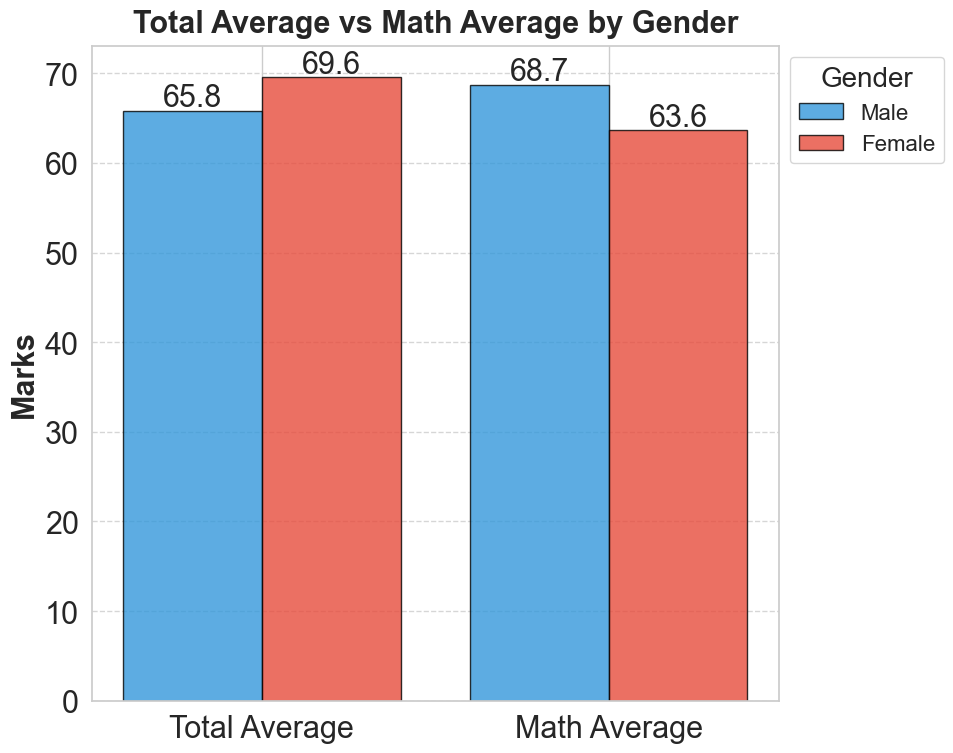

In [31]:
plt.figure(figsize=(10, 8))

X = ['Total Average', 'Math Average']

f_avg = gender_group.loc['female', 'average']
f_math = gender_group.loc['female', 'math_score'] 

m_avg = gender_group.loc['male', 'average']
m_math = gender_group.loc['male', 'math_score']

female_scores = [f_avg, f_math]
male_scores = [m_avg, m_math]

X_axis = np.arange(len(X))

# Bar chart
plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male', color='#3498db', edgecolor='black', alpha=0.8)
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female', color='#e74c3c', edgecolor='black', alpha=0.8)
plt.xticks(X_axis, X, fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel("Marks", fontsize=22, fontweight='bold')
plt.title("Total Average vs Math Average by Gender", fontsize=22, fontweight='bold', pad=10)

# Add values on the columns
for i in range(len(X)):
    plt.text(X_axis[i]-0.2, male_scores[i] + 0.5, round(male_scores[i], 1), ha='center', fontsize=22)
    plt.text(X_axis[i]+0.2, female_scores[i] + 0.5, round(female_scores[i], 1), ha='center', fontsize=22)

plt.legend(title='Gender', title_fontsize='20', loc='upper left', bbox_to_anchor=(1, 1), fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.8) 
plt.tight_layout()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

### 4.5.2. Race/ethinicity column
- How is the group-wise distribution?
- Does race/ethnicity have any impact on students' performance?

#### - Univariate analysis ( How is Group wise distribution ?)

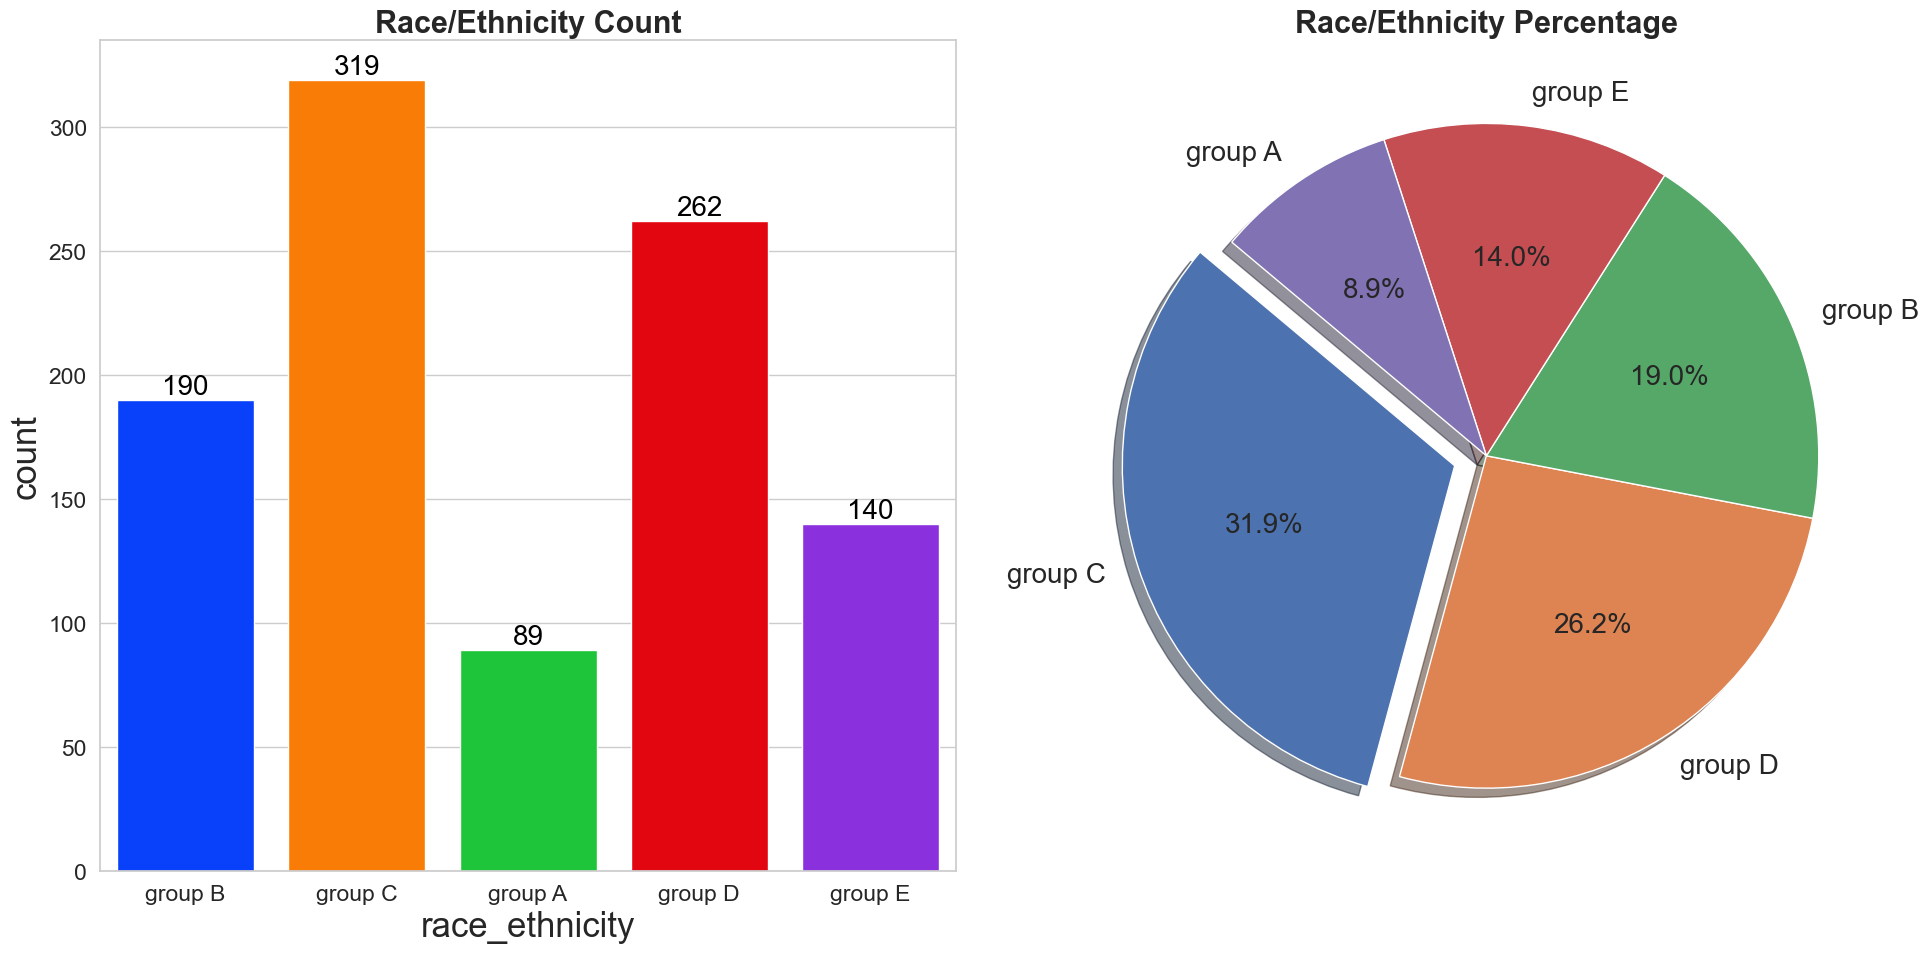

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Countplot
sns.countplot(x='race_ethnicity', data=df, palette='bright', ax=ax[0], saturation=0.95)
ax[0].set_title('Race/Ethnicity Count', fontsize=22, fontweight='bold')

# Add values on the columns
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)

# Pie chart
race_counts = df['race_ethnicity'].value_counts()

ax[1].pie(
    x=race_counts, 
    labels=race_counts.index, 
    explode=[0.1, 0, 0, 0, 0], 
    autopct='%1.1f%%', 
    shadow=True,
    startangle=140,
    textprops={'fontsize': 20}
)
ax[1].set_title('Race/Ethnicity Percentage', fontsize=22, fontweight='bold')

plt.tight_layout()

#### Insights 
- Most of the students belong to group C/group D.
- The lowest number of students belongs to group A.

#### - Bivariate analysis (Does race/ethnicity have any impact on students' performance?)

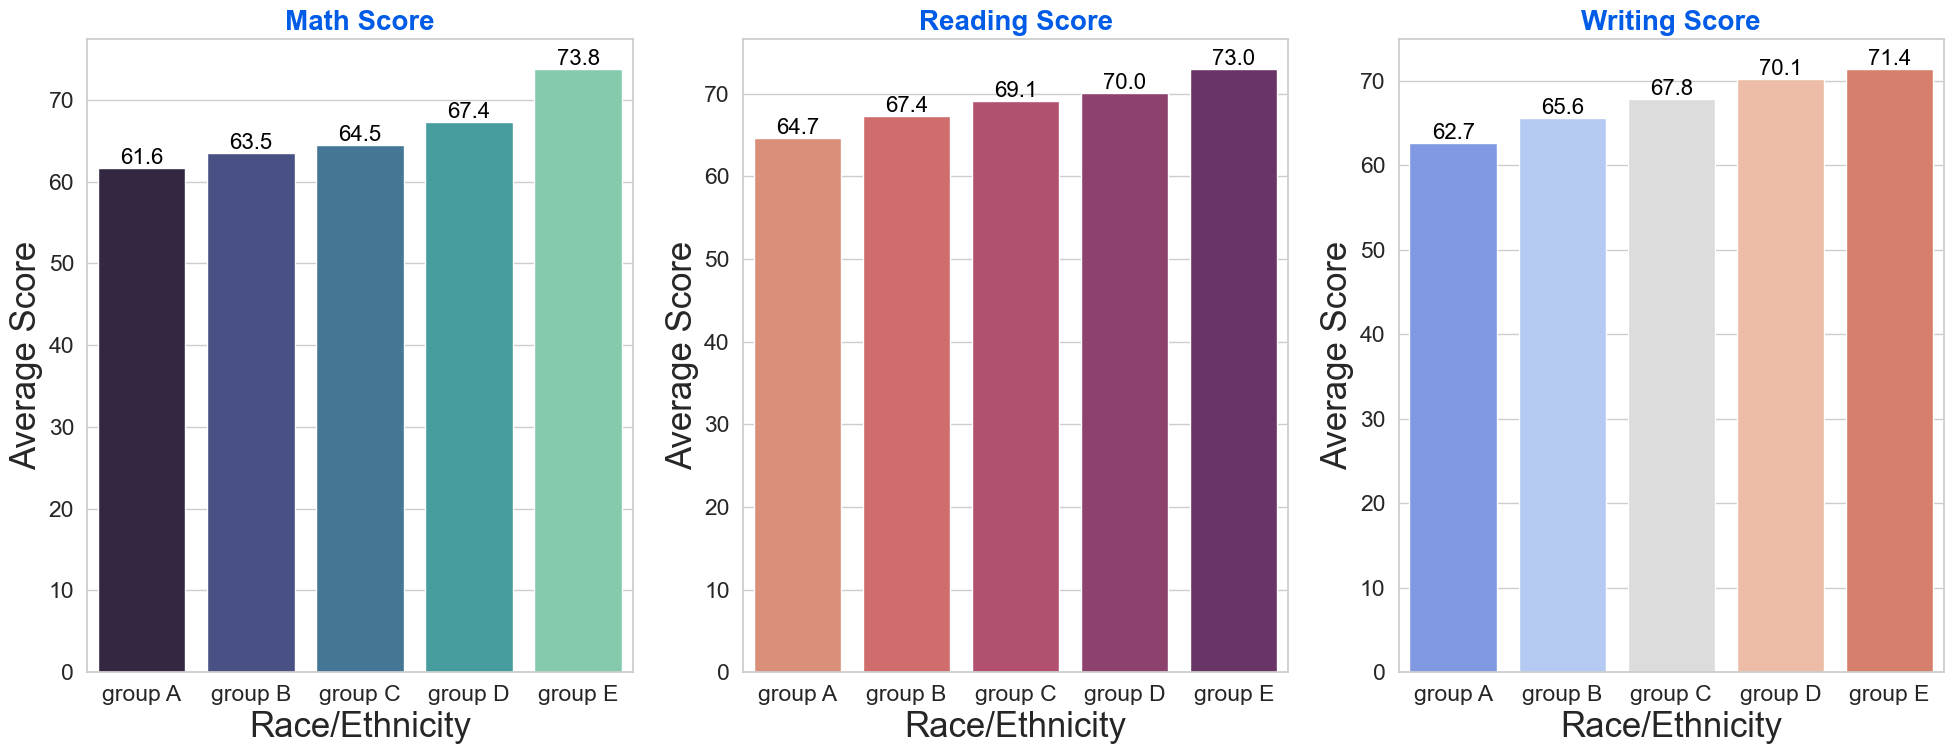

In [33]:
score_cols = ['math_score', 'reading_score', 'writing_score']
palettes = ['mako', 'flare', 'coolwarm']
titles = ['Math Score', 'Reading Score', 'Writing Score']

avg_scores = df.groupby('race_ethnicity')[score_cols].mean()

f, ax = plt.subplots(1, 3, figsize=(20, 8))

for i, col in enumerate(score_cols):
    sns.barplot(
        x=avg_scores.index, 
        y=avg_scores[col].values, 
        palette=palettes[i], 
        ax=ax[i]
    )
    
    ax[i].set_ylabel('Average Score')
    ax[i].set_xlabel('Race/Ethnicity')
    ax[i].set_title(titles[i], color='#005ce6', size=20, fontweight='bold')
    
    for container in ax[i].containers:
        ax[i].bar_label(container, color='black', size=16, fmt='%.1f')

plt.tight_layout()

#### Insights 
- Group E students have scored the highest marks. 
- Group A students have scored the lowest marks. 
- Students from a lower Socioeconomic status have a lower average in all course subjects

### 4.5.3. Parental level of education column
- What is the educational background of the student's parents?
- Does parental education have any impact on students' performance?

#### - Univariate analysis (What is the educational background of the student's parents?)

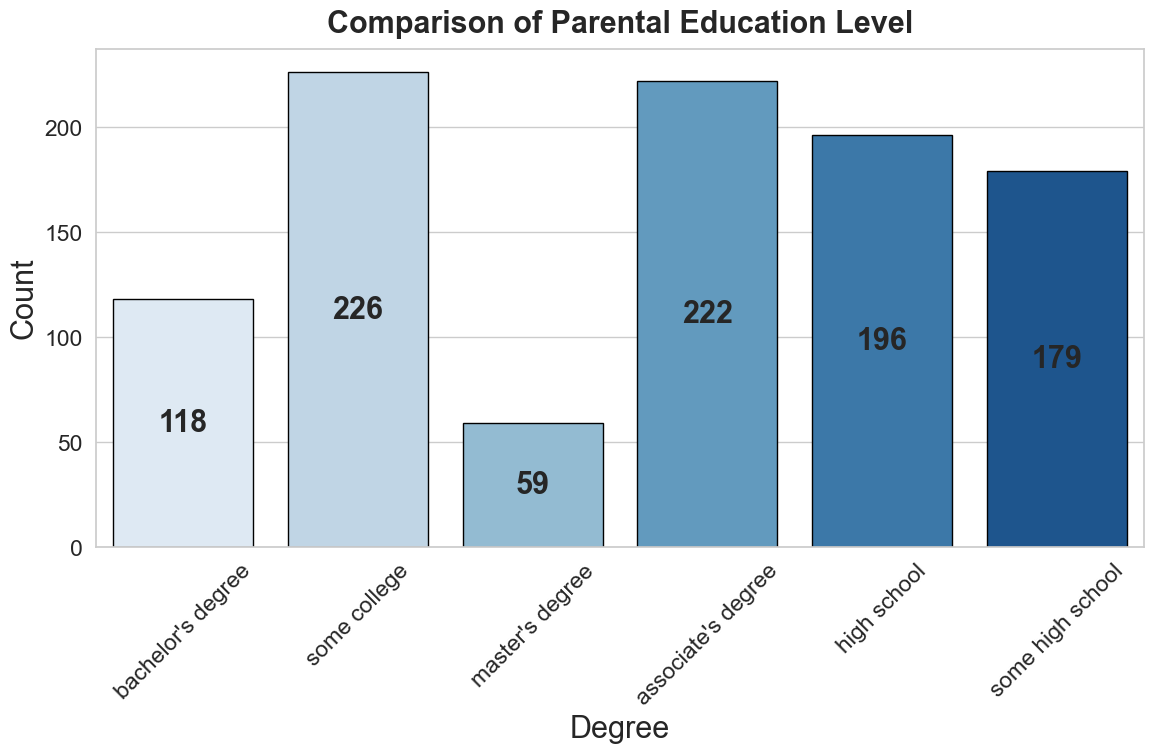

In [34]:
plt.figure(figsize=(12, 8))

sns.countplot(x='parental_level_of_education', data=df, palette='Blues', edgecolor='black')
plt.xlabel('Degree', fontsize=22)
plt.ylabel('Count', fontsize=22)
plt.title('Comparison of Parental Education Level', fontweight='bold', fontsize=22, pad=12)

ax = plt.gca() 
for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=22, fontweight='bold')

plt.xticks(rotation=45) 

plt.tight_layout()

#### Insights 
- Most parents have some college.

#### - Bivariate analysis (Does parental education have any impact on students' performance?)

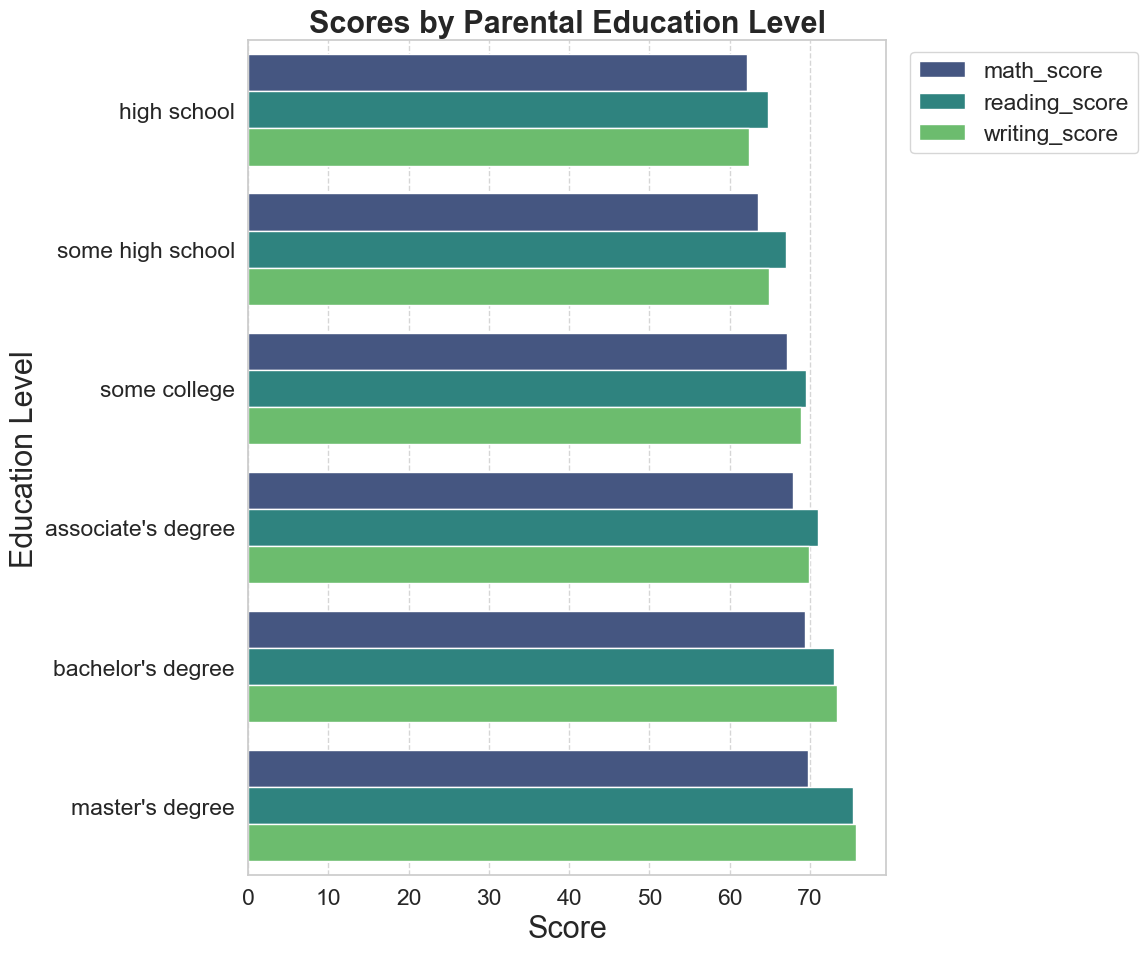

In [35]:
parent_group = df.groupby('parental_level_of_education').mean(numeric_only=True)

# Sort by average score to make the chart look more rhythmic (from low to high).
parent_group = parent_group.sort_values('average', ascending=True)

plot_cols = ['math_score', 'reading_score', 'writing_score']
plot_data = parent_group[plot_cols].reset_index().melt(id_vars='parental_level_of_education')

plt.figure(figsize=(12, 10))
sns.barplot(
    data=plot_data, 
    y='parental_level_of_education', 
    x='value', 
    hue='variable', 
    palette='viridis'
)

plt.xlabel('Score', fontsize=22)
plt.ylabel('Education Level', fontsize=22)
plt.title('Scores by Parental Education Level', fontsize=22, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()

#### Insights 
- The scores of students whose parents possess master's and bachelor's level education are higher than those of others.

### 4.5.4. Lunch column 
- What type of lunch is most common amongst students?
- What is the effect of lunch type on test results?

#### - Univariate analysis (What type of lunch is most common amongst students?)

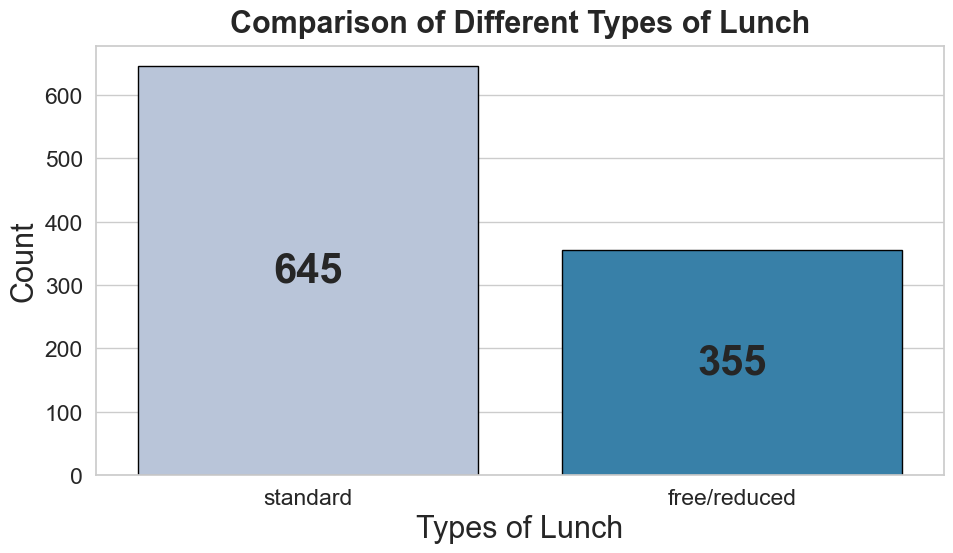

In [36]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(x='lunch', data=df, palette='PuBu', edgecolor='black')

ax.set_title('Comparison of Different Types of Lunch', fontsize=22, fontweight='bold', pad=10)
ax.set_xlabel('Types of Lunch', fontsize=22)
ax.set_ylabel('Count', fontsize=22)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=30, fontweight='bold')

plt.tight_layout()

#### Insights 
- There was a clear difference between the two groups. The majority of students used the standard meal, almost 1.8 times as many as those using the free/reduced meal.

#### - Bivariate analysis (Does lunch type intake have any impact on students' performance?)

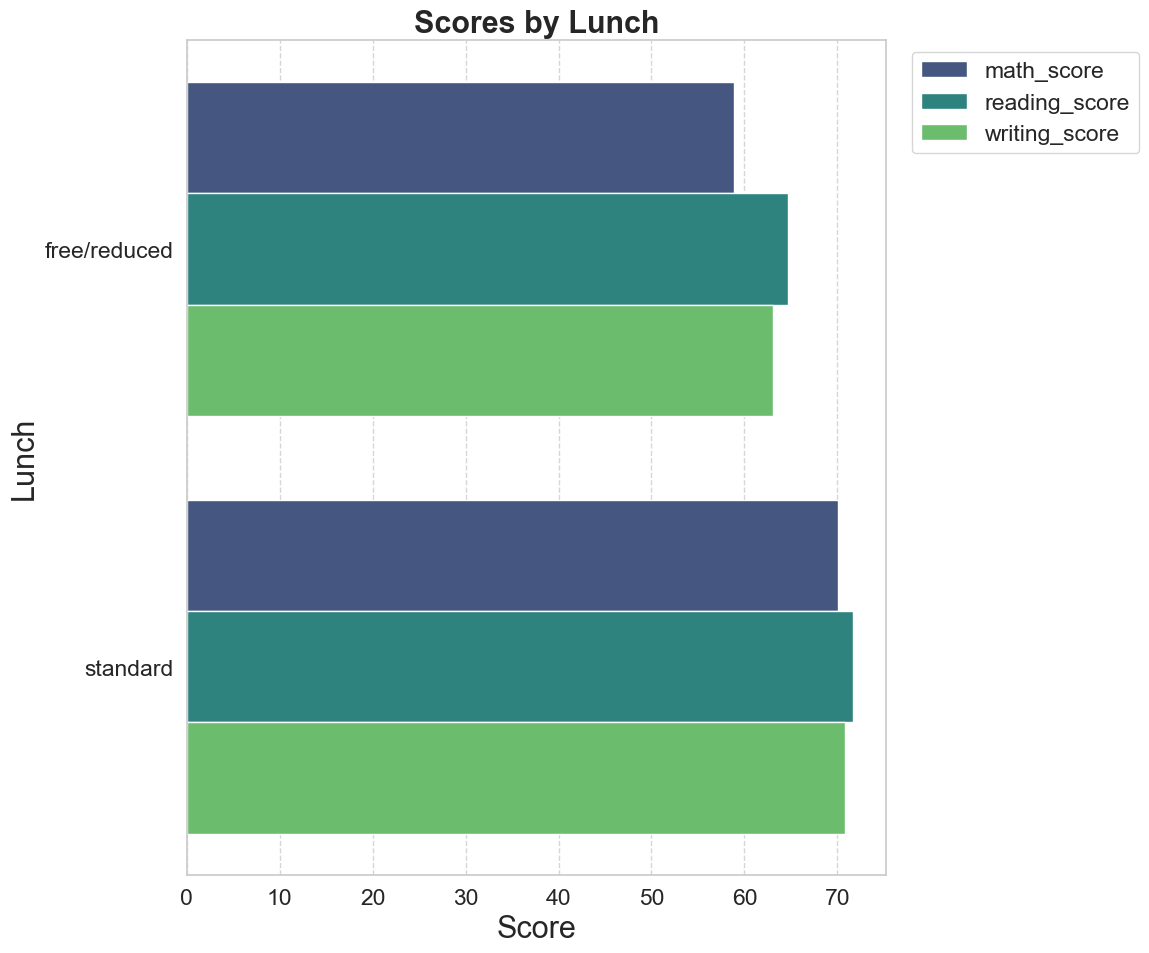

In [37]:
parent_group = df.groupby('lunch').mean(numeric_only=True)

# Sort by average score to make the chart look more rhythmic (from low to high).
parent_group = parent_group.sort_values('average', ascending=True)

plot_cols = ['math_score', 'reading_score', 'writing_score']
plot_data = parent_group[plot_cols].reset_index().melt(id_vars='lunch')

plt.figure(figsize=(12, 10))
sns.barplot(
    data=plot_data, 
    y='lunch', 
    x='value', 
    hue='variable', 
    palette='viridis'
)

plt.xlabel('Score', fontsize=22)
plt.ylabel('Lunch', fontsize=22)
plt.title('Scores by Lunch', fontsize=22, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()

#### Insights 
- Students who got Standard Lunch tend to perform better than students who got free/reduced lunch

### 4.5.5. Test preparation course column 
- Does a test preparation course have any impact on students' performance?

#### - Bivariate analysis (Does the test preparation course have any impact on students' performance?)

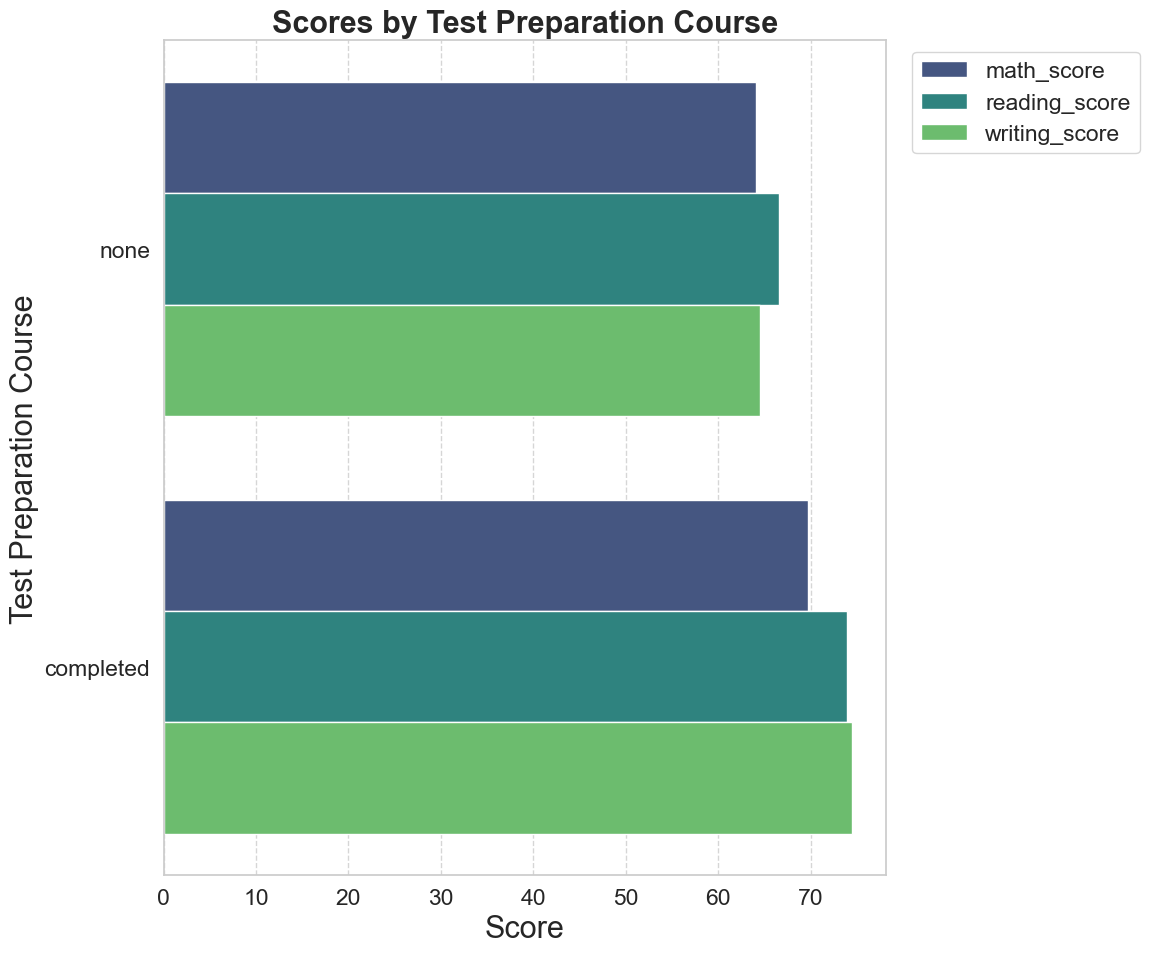

In [38]:
parent_group = df.groupby('test_preparation_course').mean(numeric_only=True)

# Sort by average score to make the chart look more rhythmic (from low to high).
parent_group = parent_group.sort_values('average', ascending=True)

plot_cols = ['math_score', 'reading_score', 'writing_score']
plot_data = parent_group[plot_cols].reset_index().melt(id_vars='test_preparation_course')

plt.figure(figsize=(12, 10))
sns.barplot(
    data=plot_data, 
    y='test_preparation_course', 
    x='value', 
    hue='variable', 
    palette='viridis'
)

plt.xlabel('Score', fontsize=22)
plt.ylabel('Test Preparation Course', fontsize=22)
plt.title('Scores by Test Preparation Course', fontsize=22, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()

#### Insights  
- Students who have completed the Test Preparation Course have scores higher in all three categories than those who have not taken the course

### 4.5.6. Impact of parental education level on student support and preparation

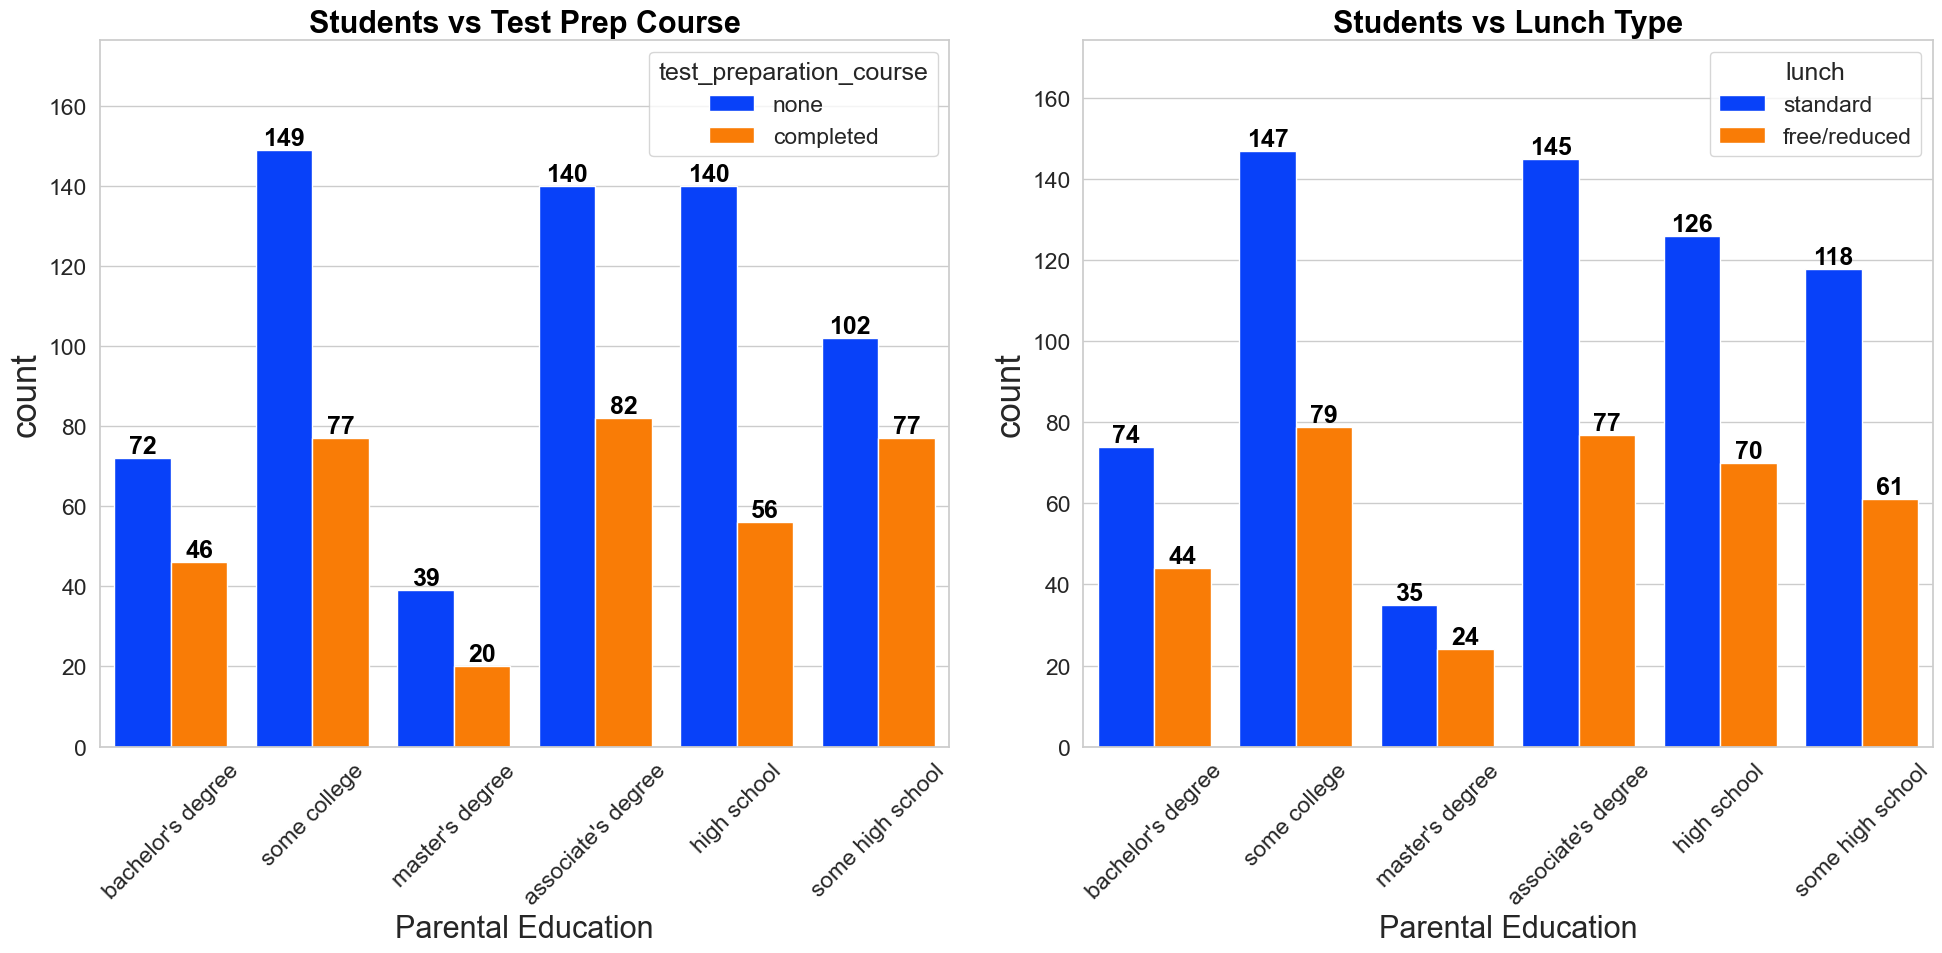

In [39]:
hue_cols = ['test_preparation_course', 'lunch']
titles = ['Students vs Test Prep Course', 'Students vs Lunch Type']

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

for i, col in enumerate(hue_cols):
    sns.countplot(
        x='parental_level_of_education', 
        data=df, 
        hue=col, 
        palette='bright', 
        saturation=0.95, 
        ax=ax[i]
    )
    
    ax[i].set_xlabel('Parental Education', size=22)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylim(0, ax[i].get_ylim()[1] + 20)
    ax[i].set_title(titles[i], color='black', size=22, fontweight='bold')    
    
    for container in ax[i].containers:
        ax[i].bar_label(container, color='black', size=18, fontweight='bold')

plt.tight_layout()

#### Insights 
- Across all parental education levels, 'Standard' lunch and 'None' test preparation are the most frequent categories. While students of parents with associate's or some college degrees form the largest subgroups in the sample, the distribution of lunch types and test prep completion remains proportionally consistent regardless of the specific degree held by the parents.

### 4.5.7. Checking outliers

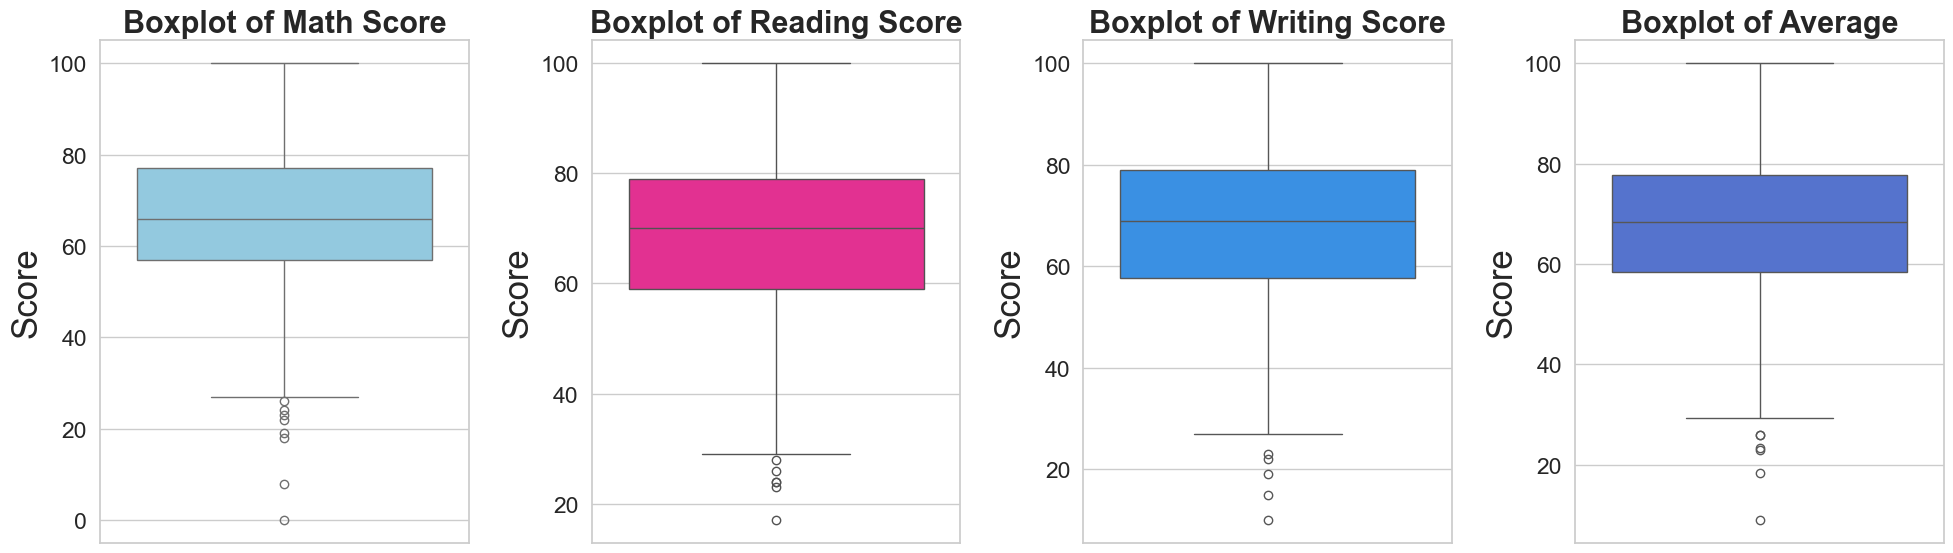

In [40]:
# 1. Danh sách cột và màu sắc tương ứng
cols = ['math_score', 'reading_score', 'writing_score', 'average']
colors = ['skyblue', 'deeppink', 'dodgerblue', 'royalblue']

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], color=colors[i], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Score')

plt.tight_layout()

### 4.5.8. Mutivariate analysis ssing pairplot

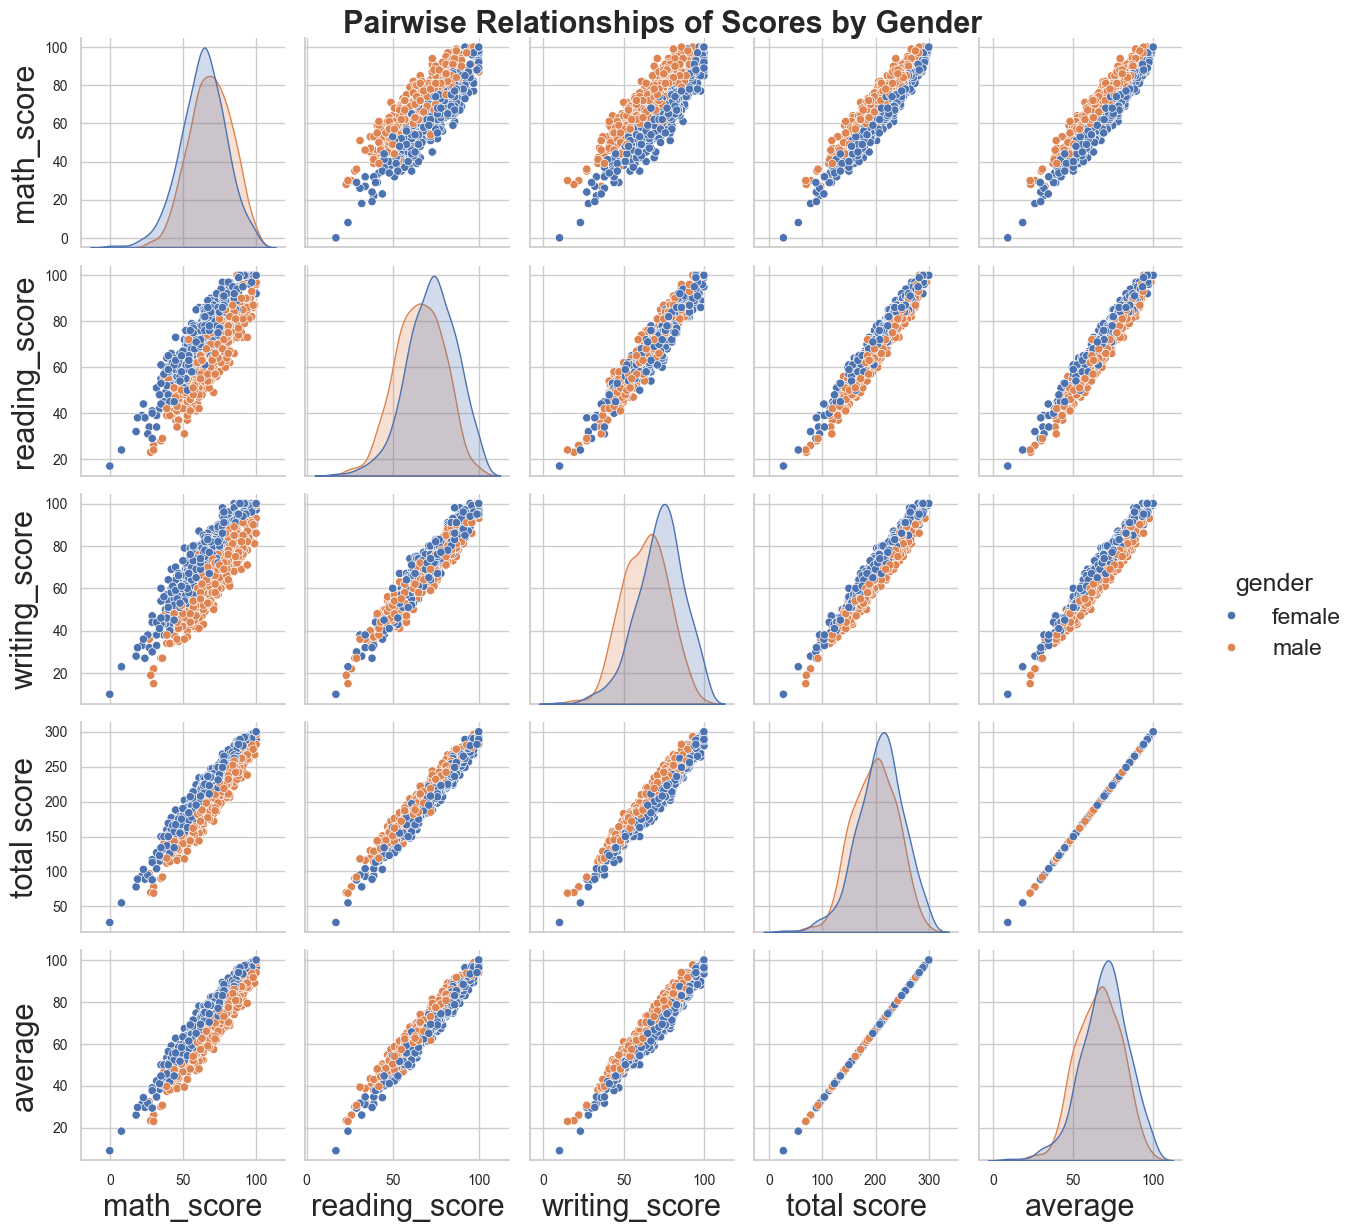

In [41]:
g = sns.pairplot(data=df, hue='gender')

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=22)
        ax.set_ylabel(ax.get_ylabel(), fontsize=22)
        
        ax.tick_params(axis='both', labelsize=10)

g.figure.suptitle('Pairwise Relationships of Scores by Gender', fontsize=22, fontweight='bold', y=1)

plt.show()

#### Insights
- From the above plot, it is clear that all the scores increase linearly with each other.

## 5. Conclusions
- Student's Performance is related to lunch, race, and parental level of education
- Females lead in pass percentage and are also the top scorers
- The student's Performance is related to the test preparation course
- Finishing the preparation course is beneficial.